In [1]:
import numpy as np
import math
from scipy.integrate import quad
from scipy.linalg import eigvalsh
from scipy.optimize import minimize_scalar
from scipy.stats import linregress
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Basic Functions

In [2]:
#kronecker product code for more than 2 inputs
def kron(*matrices):
    result = np.array([[1]])
    for matrix in matrices:
        result = np.kron(result, matrix)
    return result

#Partial Trace Code
def IntegerDigits(n, b, l):
    digits = [0] * l
    pos = l - 1
    while pos != -1:
        digits[pos] = int(n % b)
        n //= b
        pos -= 1
    return digits

def FromDigits(digits, base):
    digits = digits[::-1]
    n = 0
    for i, d in enumerate(digits):
        n += d * base**i
        
    return n

def SwapParts(digits, p1, p2):
    new = np.copy(digits)
    new[p1] = digits[p2]
    new[p2] = digits[p1]
    return new

def dTraceSystem(D,s,dimen):
    Qudits=sorted(s)
    Qudits.reverse()
    TrkM = D
    z=len(Qudits)
    
    for q in range(z):
        n=math.log(TrkM.shape[0],dimen)
        assert n % 1 == 0
        n = int(n)
        
        M=TrkM
        M = np.array(M , dtype = complex)
        k=Qudits[q]
        temp = np.zeros(M.shape[0], dtype=complex)
        if k!=n:
            for j in range(n-k):
                b={0}
                for i in range(dimen**n):
                    digits=IntegerDigits(i,dimen,n)
                    if digits[n-1] != digits[n-j-2] and i not in  b:
                        number=FromDigits(
                            SwapParts(digits, n-1, n-j-2),
                            dimen
                        )
                        b.add(number)

                        temp[:] = M[i, :]
                        M[i, :] = M[number, :]
                        M[number, :] = temp

                        temp[:] = M[:, i]
                        M[:, i] = M[:, number]
                        M[:, number] = temp
        
        TrkM=[]
        for p in range(0,dimen**n,dimen):
            TrkM.append(
                sum(
                    M[p+h, h:dimen**n:dimen]
                    for h in range(dimen)
                )
            )
        TrkM = np.array(TrkM)
    
    return TrkM
#Recall matrix as dTraceSystem(matrix,[systems I want to trace out],dimension of system)

#defining basis vectors

#zero vector and its conjugate transpose                                         
zero= np.array([[1],[0]])
zeroCT=np.conjugate(zero.T)
#one vector and its conjugate transpose
one=np.array([[0],[1]])
oneCT=np.conjugate(one.T)
#plus vector and its conjugate transpose
plus=np.array([[1],[1]])*1/math.sqrt(2)
plusCT=np.conjugate(plus.T)
#minus vector and its conjugate transpose
minus=np.array([[1],[-1]])*1/math.sqrt(2)
minusCT=np.conjugate(minus.T)
#plusy and its conjugate transpose
plusy=np.array([[1],[complex(0.0, 1)]])*1/math.sqrt(2)
plusyCT=np.conjugate(plusy.T)
#minusy and its conjugate transpose
minusy=np.array([[1],[complex(0.0, -1)]])*1/math.sqrt(2)
minusyCT=np.conjugate(minusy.T)
#defining the Bell states
phiplus=(np.kron(zero, zero)+np.kron(one, one))*1/math.sqrt(2)
phiminus=(np.kron(zero, zero)-np.kron(one, one))*1/math.sqrt(2)
psiplus=(np.kron(zero, one)+np.kron(one, zero))*1/math.sqrt(2)
psiminus=(np.kron(zero, one)-np.kron(one, zero))*1/math.sqrt(2)
#defining the outer product of the Bell states
Phiplus=phiplus@np.conjugate(phiplus.T)
Phiminus=phiminus@np.conjugate(phiminus.T)
Psiplus=psiplus@np.conjugate(psiplus.T)
Psiminus=psiminus@np.conjugate(psiminus.T)
#defining Pauli matrices
pauliX=np.array([[0,1],[1,0]])
pauliY=np.array([[0,complex(0,-1)],[complex(0,1),0]])
pauliZ=np.array([[1,0],[0,-1]])

# Bell-Diagonal Map

In [3]:
def r(p, q):
    return np.array([
        p[3]*q[0] + p[2]*q[1] + p[1]*q[2] + p[0]*q[3],
        p[2]*q[0] + p[3]*q[1] + p[0]*q[2] + p[1]*q[3],
        p[1]*q[0] + p[0]*q[1] + p[3]*q[2] + p[2]*q[3],
        p[0]*q[0] + p[1]*q[1] + p[2]*q[2] + p[3]*q[3]
    ])

def rNtimes(p, n):
    if n == 1:
        return r(p, p)
    else:
        return r(rNtimes(p, n-1), p)

# GKP

In [4]:
#Defining parameters for GKP states


# transmissivity for QR setup
def new_eta(L, n):
    alpha_dB_per_km = 0.2
    alpha = (alpha_dB_per_km / 10) * np.log(10)  # convert dB/km to 1/km
    return np.exp(-alpha * L / (n + 1))  # eta ∈ [0, 1]

#Quality of GKP state
def sigmaloss(sigma , L , n):
    eta = new_eta(L , n)
    return np.sqrt(eta * sigma**2 + (1 - eta))


#Error functions
def f(x , mu , sigma , L , n):
    s = sigmaloss(sigma , L , n)
    return np.exp(-(x - mu)**2 / (2 * s**2))/(s * np.sqrt(2*np.pi))

def Pc(sigma , nu , L , n):
    integrand = lambda x: f(x , 0 , sigma , L , n)
    lower = -0.5 * np.sqrt(np.pi) + nu
    upper =  0.5 * np.sqrt(np.pi) - nu
    return quad(integrand, lower, upper)[0] 
    
def Pf(sigma , nu , L , n):
    integrand = lambda x: f(x, 0, sigma, L , n)
    lower = 0.5 * np.sqrt(np.pi) + nu
    upper = 1.5 * np.sqrt(np.pi) - nu
    return 2 * quad(integrand, lower, upper)[0]



#Bell state mixture probabilities


def p1(sigma , nu , L , n):
    pc = Pc(sigma , nu , L , n)
    pf = Pf(sigma , nu , L , n)
    return (pc**2) / (pc + pf)**2

def p2(sigma , nu , L , n):
    pc = Pc(sigma , nu , L , n)
    pf = Pf(sigma , nu , L , n)
    return (pc * pf) / (pc + pf)**2

def p3(sigma , nu , L , n):
    pc = Pc(sigma , nu , L , n)
    pf = Pf(sigma , nu , L , n)
    return (pf**2) / (pc + pf)**2



#Mixture of Bell states

def new_vector(sigma , nu , L , n):
    return np.array([
        p1(sigma , nu , L , n) , 
        p2(sigma , nu , L , n) , 
        p2(sigma , nu , L , n) , 
        p3(sigma , nu , L , n)
        ])


#von Neumann entropy

def vonneumann(mat):
    evals = eigvalsh(mat)
    evals = np.clip(evals, 1e-16 , 1)
    return -np.sum(evals * np.log2(evals))



# hashing bound

def hashing_bound(mat):
    sAB = vonneumann(mat)
    sA = vonneumann(dTraceSystem(mat , [2] , 2))
    sB = vonneumann(dTraceSystem(mat , [1] , 2))
    return max(sA - sAB , sB - sAB)



# chain function

def chain_function(vec , n):
    return rNtimes(vec , n)



# building the chain states

def BSM_mixture_chain(vec):
    return vec[0] * Phiplus + vec[1] * Phiminus + vec[2] * Psiplus + vec[3] * Psiminus
 

# defining the probability of success for repeaters

# BSM swaps are no longer deterministic
# we model realistic repeater architectures
# these architectures perform probabilistic entanglement generation
# we only succeed when ALL elementary links generate entangled pairs
# AND all BSM swaps succeed

# these probability of successes have been adjusted in each respectiv hashing rate definition

#GKP chains

# hashing rate
def hashing_rate(sigma , nu , L , n , M , q , tau , m):

    pc = Pc(sigma , nu , L , n)
    pf = Pf(sigma , nu , L , n)

    # probability of BSM swap
    pSWAP = (pc + pf)**2
    # probability single element success
    pELEM = 1 - (1 - pSWAP)**(M * m)
    # probability successful connection between end users
    pNETWORK = pELEM**(n + 1) * q**n
    # achievable rate of entanglement generation for the network
    rate = pNETWORK / (tau * m)

    vec = chain_function(new_vector(sigma , nu , L , n) , n)
    
    return rate * hashing_bound(BSM_mixture_chain(vec))


# optimal hashing rate
def optimal_hashing_rate(sigma , L , n , M , q , tau , m , return_nu = False):
    def neg_rate(nu):
        try:
            value = hashing_rate(sigma , nu , L , n , M , q , tau , m)
            return -value if value > 0 else np.inf
        except Exception:
            return np.inf

    result = minimize_scalar(neg_rate, bounds=(0, 0.5 * np.sqrt(np.pi)), method='bounded')
    rate = -result.fun

    if not np.isfinite(rate) or rate <= 0:
        rate = 0.0

    if return_nu:
        return rate , result.x  # return rate, ν
    return rate

# Hashing Rate vs Distance for $M=1$ , $m=20$

In [5]:
plt.figure(dpi  = 1000)

Ls = np.arange(0 , 150 , 1.5)

sigma1 = np.sqrt(0.01)
rates1s1 = [optimal_hashing_rate(sigma1 , L , 1 , 1 , 0.7 , 1e-8 , 20) for L in Ls]
rates2s1 = [optimal_hashing_rate(sigma1 , L , 2 , 1 , 0.7 , 1e-8 , 20) for L in Ls]
rates4s1 = [optimal_hashing_rate(sigma1 , L , 4 , 1 , 0.7 , 1e-8 , 20) for L in Ls]
rates8s1 = [optimal_hashing_rate(sigma1 , L , 8 , 1 , 0.7 , 1e-8 , 20) for L in Ls]
rates16s1 = [optimal_hashing_rate(sigma1 , L , 16 , 1 , 0.7 , 1e-8 , 20) for L in Ls]

/Users/conallcampbell/Documents/Conall Campbell/My Life/3. University of Maryland/Postdoc/Project 3 - Genetic Algorithm/QSim-main/venv/lib/python3.12/site-packages/scipy/optimize/_optimize.py:2358: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/conallcampbell/Documents/Conall Campbell/My Life/3. University of Maryland/Postdoc/Project 3 - Genetic Algorithm/QSim-main/venv/lib/python3.12/site-packages/scipy/optimize/_optimize.py:2359: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


<Figure size 6400x4800 with 0 Axes>

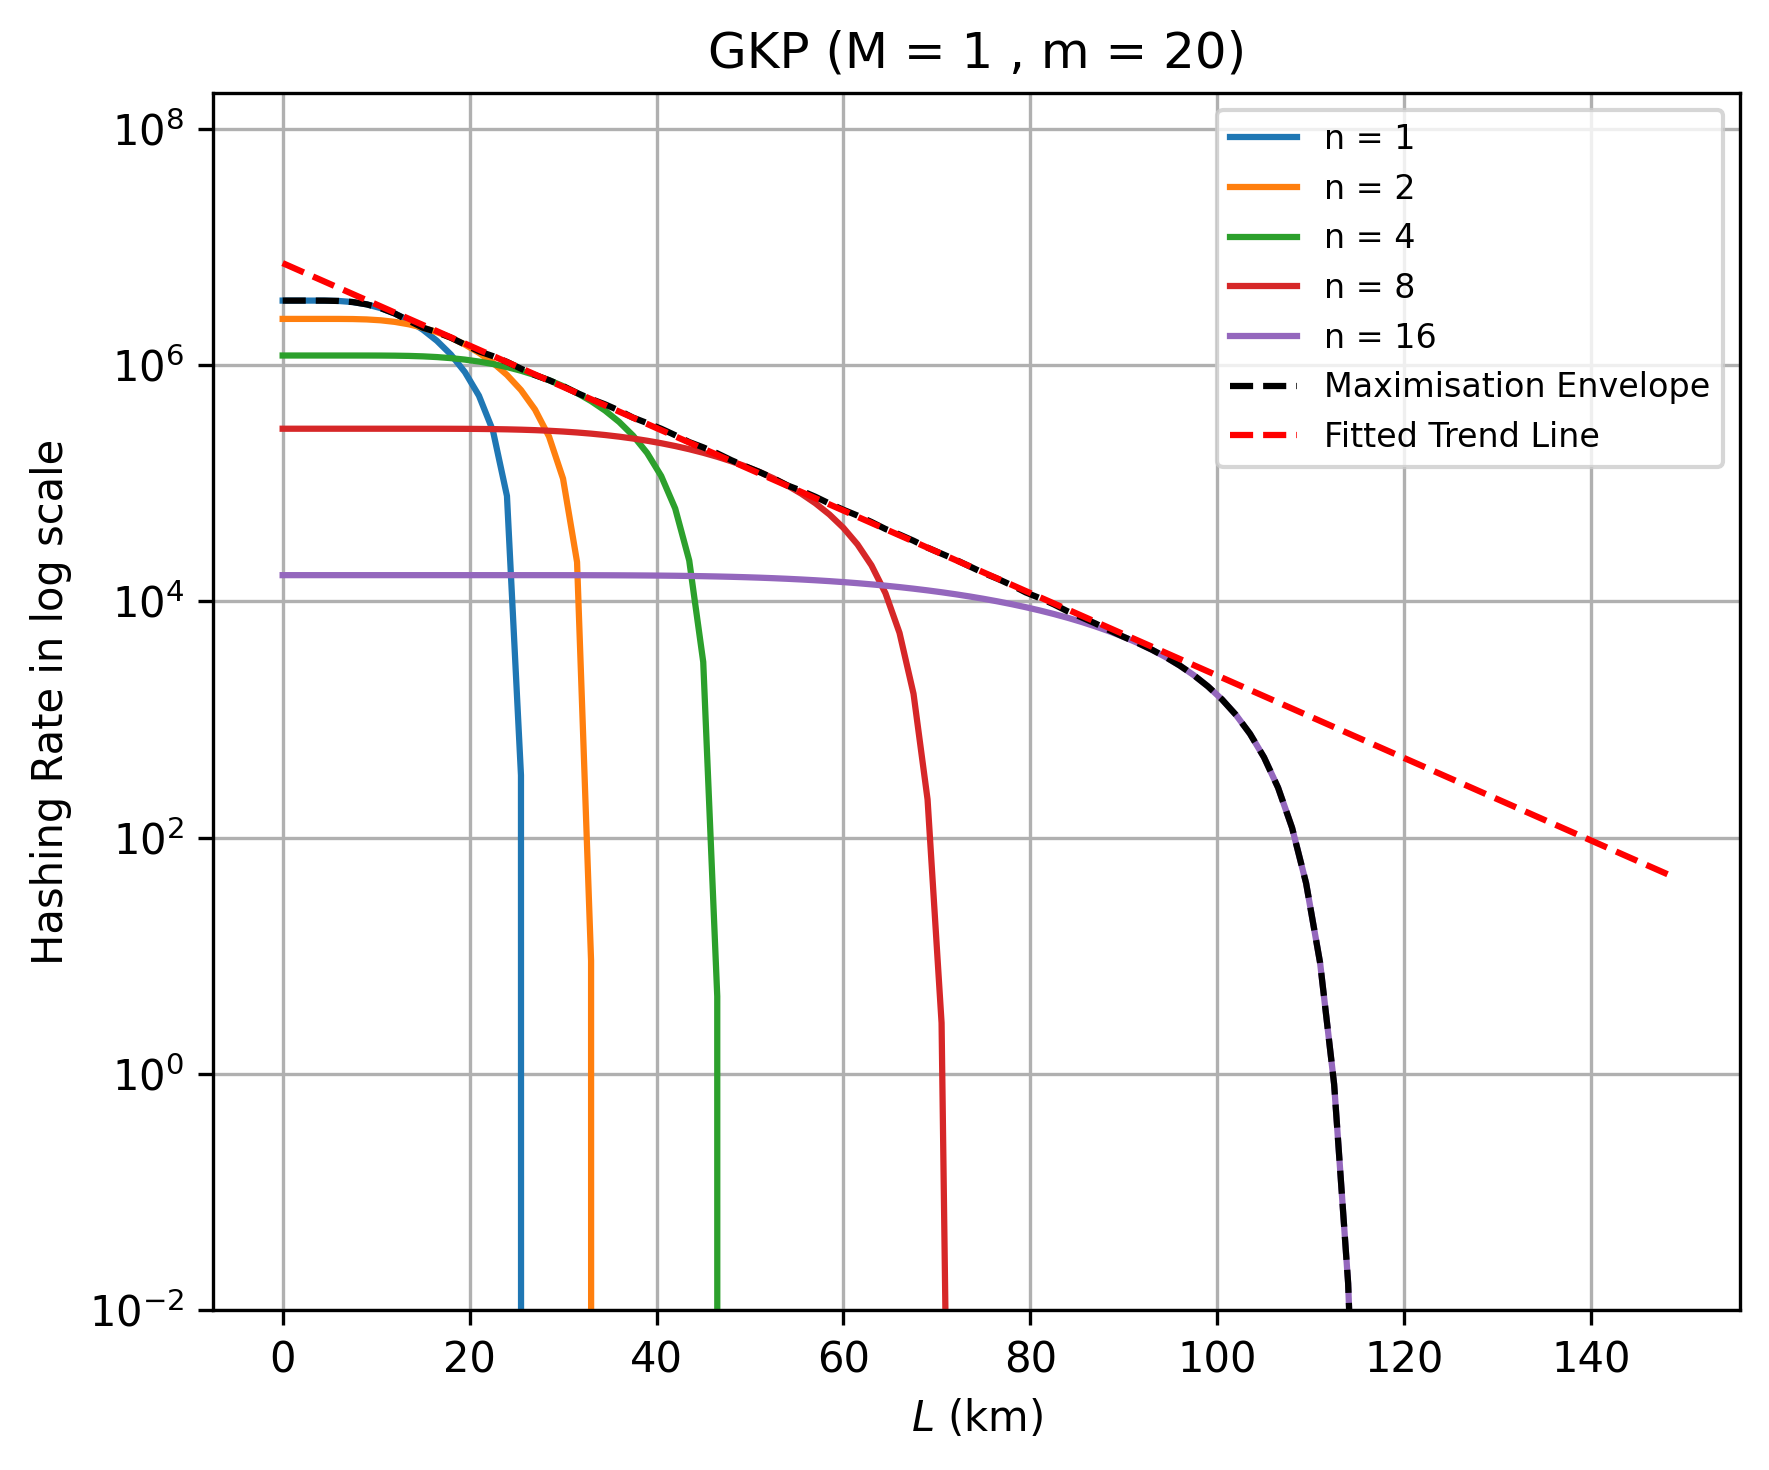

In [7]:
q = 0.7
tau = 1e-8
M = 1
alpha = (np.log(10) / 10) * 0.2

fig, ax = plt.subplots(figsize=(6, 5),dpi = 300)
ax.set_yscale("log")
ax.set_title("GKP (M = 1 , m = 20)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e-2, top=2e8)
ax.grid(True)

n_vals = [1 , 2 , 4 , 8 , 16]

m = 20
Ls = np.array(Ls)  # ensure it's an array
gkp_list = [rates1s1 , rates2s1 , rates4s1 , rates8s1 , rates16s1]

color_cycle = plt.get_cmap("tab10")

for i, rate_curve in enumerate(gkp_list):
    n = n_vals[i]
    color = color_cycle(i)

    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)

n_scan_vals = np.arange(1 , 17)

rate_envelope = []

for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        _, nu_opt = optimal_hashing_rate(sigma1, L, n, M, q, tau, m, return_nu=True)
        pc = Pc(sigma1, nu_opt, L, n)
        pf = Pf(sigma1, nu_opt, L, n)
        pSWAP = (pc + pf)**2
        pELEM = 1 - (1 - pSWAP)**(M * m)
        pNETWORK = pELEM**(n + 1) * q**n
        rate = pNETWORK / (tau * m)

        # Include hashing bound
        vec = chain_function(new_vector(sigma1, nu_opt, L, n), n)
        state_bound = hashing_bound(BSM_mixture_chain(vec))
        true_hashing_rate = rate * state_bound
        best_rate = max(best_rate , true_hashing_rate)
    rate_envelope.append(best_rate)
rate_envelope = np.array(rate_envelope)

ax.plot(Ls, np.maximum(rate_envelope , 1e-30), color="black", linestyle="--", linewidth=1.5, label="Maximisation Envelope")

fit_mask = (Ls > 10) & (Ls < 90) & np.isfinite(rate_envelope) & (rate_envelope > 0)
log_env = np.log(rate_envelope[fit_mask])
slope, intercept, *_ = linregress(Ls[fit_mask], log_env)
predicted_env1 = np.exp(slope * Ls + intercept)
ax.plot(Ls, predicted_env1, color="red", linestyle="--", label="Fitted Trend Line")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Maximisation over $(n,m)$ for $M=1$

In [44]:
def compute_gkp_envelope(m, sigma, Ls, M, q, tau, n_vals, n_scan_vals):
    fixed_n_data = {n: {"rate": []} for n in n_vals}
    rate_envelope = []

    for L in Ls:
        best_rate = 0.0

        for n in n_scan_vals:
            _, nu_opt = optimal_hashing_rate(sigma, L, n, M, q, tau, m, return_nu=True)

            pc = Pc(sigma, nu_opt, L, n)
            pf = Pf(sigma, nu_opt, L, n)

            pSWAP = (pc + pf)**2
            pELEM = 1 - (1 - pSWAP)**(M * m)
            pNETWORK = pELEM**(n + 1) * q**n
            rate = pNETWORK / (tau * m)

            vec = chain_function(new_vector(sigma, nu_opt, L, n), n)
            state_bound = max(hashing_bound(BSM_mixture_chain(vec)), 0.0)

            true_hashing_rate = max(rate * state_bound, 0.0)
            best_rate = max(best_rate, true_hashing_rate)

            if n in fixed_n_data:
                fixed_n_data[n]["rate"].append(true_hashing_rate)

        rate_envelope.append(best_rate)

    rate_envelope = np.array(rate_envelope)

    for n in n_vals:
        fixed_n_data[n]["rate"] = np.array(fixed_n_data[n]["rate"])

    fit_mask = (Ls > 10) & (Ls < 40) & np.isfinite(rate_envelope) & (rate_envelope > 0)
    log_env = np.log(rate_envelope[fit_mask])
    slope, intercept, *_ = linregress(Ls[fit_mask], log_env)

    return {
        "m": m,
        "Linear Regression slope": slope,
        "Linear Regression intercept": intercept,
        "Hashing Rate curves": rate_envelope,
        "fixed_n_data": fixed_n_data,
    }

In [45]:
Ls = np.arange(0, 50, 0.1)
Ls = np.array(Ls)

sigma = np.sqrt(0.01)
M = 1
q = 0.7
tau = 1e-8

m_values = np.arange(1, 30)
n_vals = [1, 2, 4, 8, 16]
n_scan_vals = np.arange(1, 17)

results_by_m = {}
envs = {}

for m in m_values:
    print("Computing envelope for m =", m)

    out = compute_gkp_envelope(m, sigma, Ls, M, q, tau, n_vals, n_scan_vals)

    predicted_env = np.exp(out["Linear Regression intercept"] + out["Linear Regression slope"] * Ls)

    results_by_m[m] = out
    envs[m] = predicted_env

Computing envelope for m = 1
Computing envelope for m = 2
Computing envelope for m = 3
Computing envelope for m = 4
Computing envelope for m = 5
Computing envelope for m = 6
Computing envelope for m = 7
Computing envelope for m = 8
Computing envelope for m = 9
Computing envelope for m = 10
Computing envelope for m = 11
Computing envelope for m = 12
Computing envelope for m = 13
Computing envelope for m = 14
Computing envelope for m = 15
Computing envelope for m = 16
Computing envelope for m = 17
Computing envelope for m = 18
Computing envelope for m = 19
Computing envelope for m = 20
Computing envelope for m = 21
Computing envelope for m = 22
Computing envelope for m = 23
Computing envelope for m = 24
Computing envelope for m = 25
Computing envelope for m = 26
Computing envelope for m = 27
Computing envelope for m = 28
Computing envelope for m = 29


In [46]:
# matrix whose rows are the fitted envelopes for each m
gkp_env_matrix = np.array([envs[m] for m in m_values])
# fully maximized envelope over both n and m
fully_maximized_gkp_env = np.max(gkp_env_matrix, axis=0)

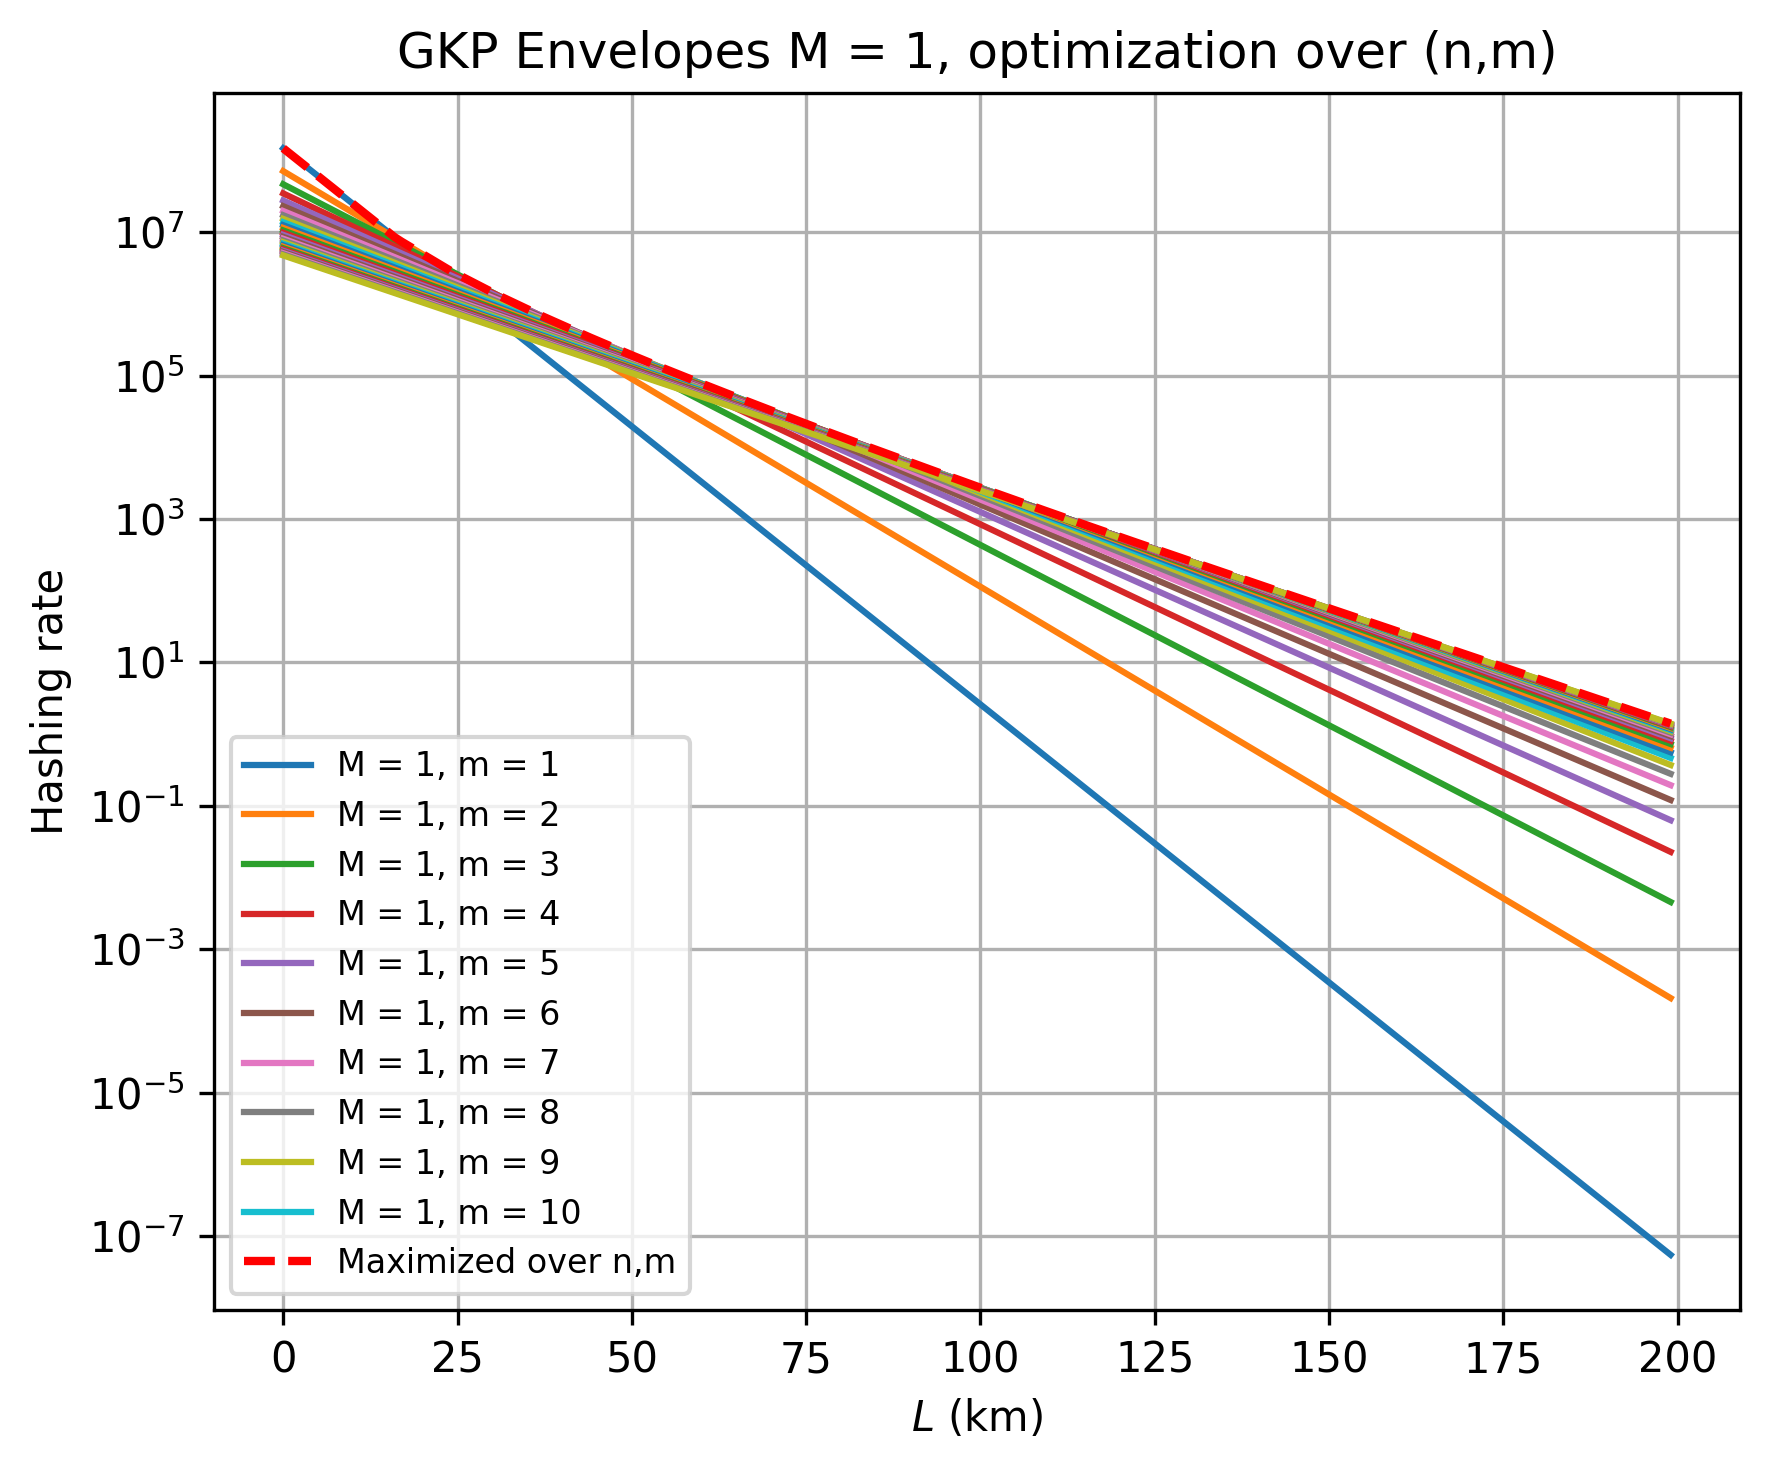

In [10]:
fig, ax = plt.subplots(figsize=(6,5), dpi=300)

ax.set_yscale("log")
ax.set_title("GKP Envelopes M = 1, optimization over (n,m)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

for i, m in enumerate(m_values):
    label = f"M = 1, m = {m_values[i]}" if i < 10 else None
    ax.plot(Ls,envs[m],color=color_cycle(i % 10),linestyle="-",label=label)
ax.plot(Ls,fully_maximized_gkp_env,color="red",linestyle="--",linewidth=2,label="Maximized over n,m")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Test

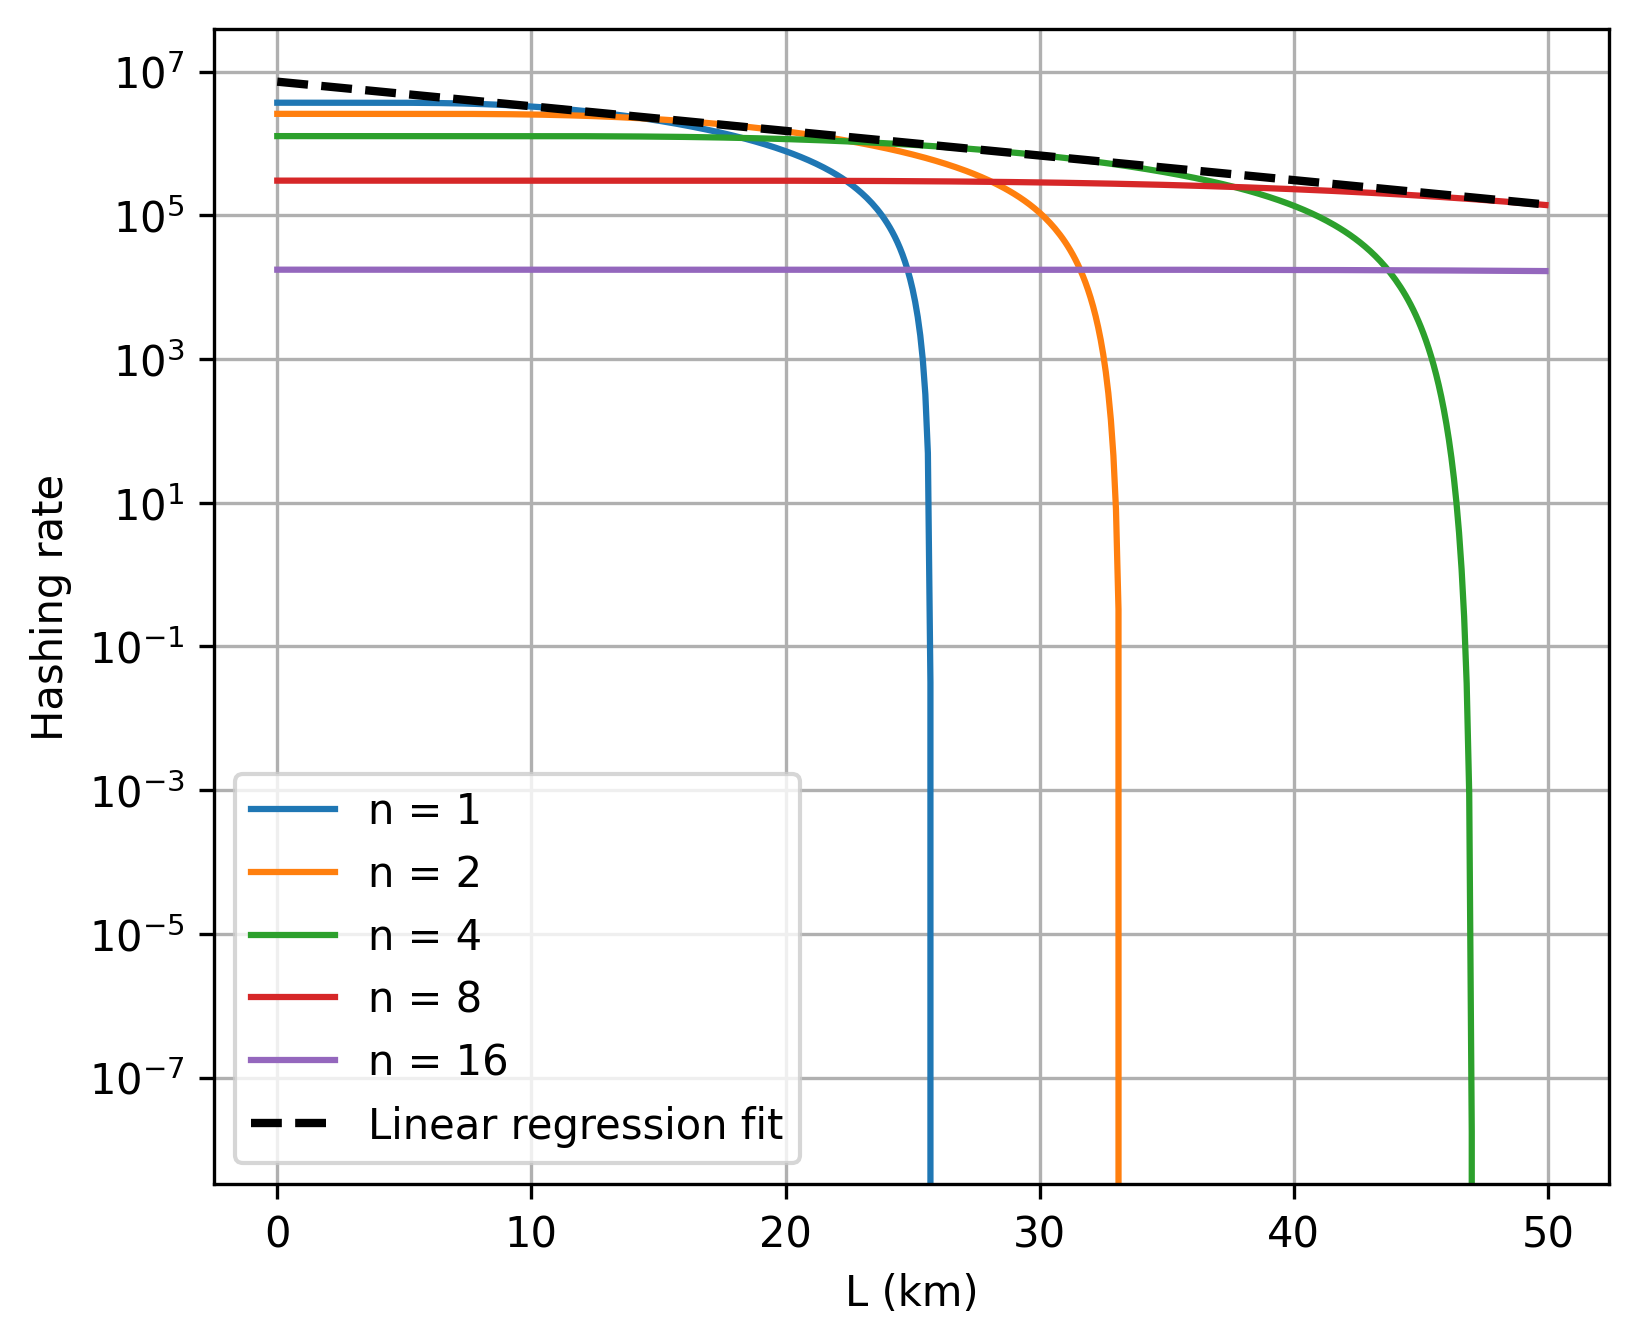

In [47]:
m = 19
out = results_by_m[m]

plt.figure(figsize=(6,5), dpi=300)

# plot the fixed-n rate curves
for n in n_vals:
    plt.semilogy(
        Ls,
        out["fixed_n_data"][n]["rate"],
        label=f"n = {n}"
    )

# plotting the linear regression fit
plt.semilogy(
    Ls,
    envs[m],
    "k--",
    linewidth=2,
    label="Linear regression fit"
)

plt.grid(True)
plt.legend()
plt.xlabel("L (km)")
plt.ylabel("Hashing rate")
plt.show()

# Dual-Rail

In [48]:
# Dual Rail
def DualRailState(eta , Pd , Vis):
    return 4 * np.array(
        [
            [1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta), 0 , 0 , 0] ,
            [0 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta) + 1/16 * ((1 - Pd)**4) * eta , 1/16 * ((1 - Pd)**4) * eta * Vis**2 , 0] ,
            [0 , 1/16 * ((1 - Pd)**4) *eta * Vis**2 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta) + 1/16 * ((1 - Pd)**4) * eta , 0] ,
            [0 , 0 , 0 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta)]
        ]
    )
# normalised quantum state for dual-rail entangled memory pair
def QStateDual(eta , Pd , Vis):
    state = DualRailState(eta , Pd , Vis)
    tr = np.trace(DualRailState(eta , Pd , Vis))
    # avoiding division by 0
    if tr == 0 or not np.isfinite(tr):
        return np.zeros_like(state)
    return state / tr

# hashing rate
def DRhashingrate(L , n , M , q , tau , m):
    eta = new_eta(L , n)
    PsuccDR = np.trace(DualRailState(eta , 0 , 1))

    # probability of BSM swap
    pSWAP = PsuccDR
    # probability single element success
    pELEM = 1 - (1 - pSWAP)**(M * m)
    # probability successful connection between end users
    pNETWORK = pELEM**(n + 1) * q**n
    # achievable rate of entanglement generation for the network
    rate = pNETWORK / (tau * m)

    if n == 1:
        return rate * hashing_bound(QStateDual(eta , 0 , 1))
    else:
        vec = rNtimes(np.linalg.eigvalsh(QStateDual(eta , 0 , 1)) , n - 1)
        rho = BSM_mixture_chain(vec)
        return rate * hashing_bound(rho)

In [49]:
Ls = np.arange(0 , 50 , 0.1)

rates1DR = [DRhashingrate(L , 1 , 1 , 0.7 , 1e-8 , 1) for L in Ls]
rates2DR = [DRhashingrate(L , 2 , 1 , 0.7 , 1e-8 , 1) for L in Ls]
rates4DR = [DRhashingrate(L , 4 , 1 , 0.7 , 1e-8 , 1) for L in Ls]
rates8DR = [DRhashingrate(L , 8 , 1 , 0.7 , 1e-8 , 1) for L in Ls]
rates16DR = [DRhashingrate(L , 16 , 1 , 0.7 , 1e-8 , 1) for L in Ls]

In [50]:
def compute_dr_envelope_and_fit(Ls, n_scan_vals, M, q, tau, m, L_min=0, L_max=150):
    rate_envelope = []
    for L in Ls:
        best_rate = 0
        for n in n_scan_vals:
            try:
                rate = DRhashingrate(L, n, M, q, tau, m)
                if np.isfinite(rate):
                    best_rate = max(best_rate, rate)
            except:
                continue
        rate_envelope.append(best_rate)

    rate_env_arr = np.array(rate_envelope)
    valid_mask = (rate_env_arr > 0) & np.isfinite(rate_env_arr)
    fit_Ls = Ls[valid_mask]
    log_env = np.log(rate_env_arr[valid_mask])

    fit_mask = (fit_Ls > L_min) & (fit_Ls < L_max)
    slope, intercept, *_ = linregress(fit_Ls[fit_mask], log_env[fit_mask])
    predicted_env = np.exp(slope * Ls + intercept)

    return rate_env_arr, predicted_env

n_scan_vals = np.arange(1, 16)

dr_envelopes = []
rate_env, predicted_env = compute_dr_envelope_and_fit(Ls, n_scan_vals, M=1, q=0.7, tau=1e-8, m=1)
dr_envelopes.append(predicted_env)

In [51]:
Ls = np.arange(0 , 50 , 0.1)
n_scan_vals = np.arange(1, 16)

m_values = np.arange(1, 1000)

dr_envs = []

for m in m_values:
    print("Computing DR envelope for m =", m)
    _, predicted_env = compute_dr_envelope_and_fit(Ls,n_scan_vals,M=1,q=0.7,tau=1e-8,m=m)
    dr_envs.append(predicted_env)

Computing DR envelope for m = 1
Computing DR envelope for m = 2
Computing DR envelope for m = 3
Computing DR envelope for m = 4
Computing DR envelope for m = 5
Computing DR envelope for m = 6
Computing DR envelope for m = 7
Computing DR envelope for m = 8
Computing DR envelope for m = 9
Computing DR envelope for m = 10
Computing DR envelope for m = 11
Computing DR envelope for m = 12
Computing DR envelope for m = 13
Computing DR envelope for m = 14
Computing DR envelope for m = 15
Computing DR envelope for m = 16
Computing DR envelope for m = 17
Computing DR envelope for m = 18
Computing DR envelope for m = 19
Computing DR envelope for m = 20
Computing DR envelope for m = 21
Computing DR envelope for m = 22
Computing DR envelope for m = 23
Computing DR envelope for m = 24
Computing DR envelope for m = 25
Computing DR envelope for m = 26
Computing DR envelope for m = 27
Computing DR envelope for m = 28
Computing DR envelope for m = 29
Computing DR envelope for m = 30
Computing DR envelo

In [52]:
# dr_envs is already a list of arrays, one per m
env_matrix = np.array(dr_envs)  # shape: (len(m_values), len(Ls))
# fully maximized envelope over both n and m
fully_maximized_env = np.max(env_matrix, axis=0)

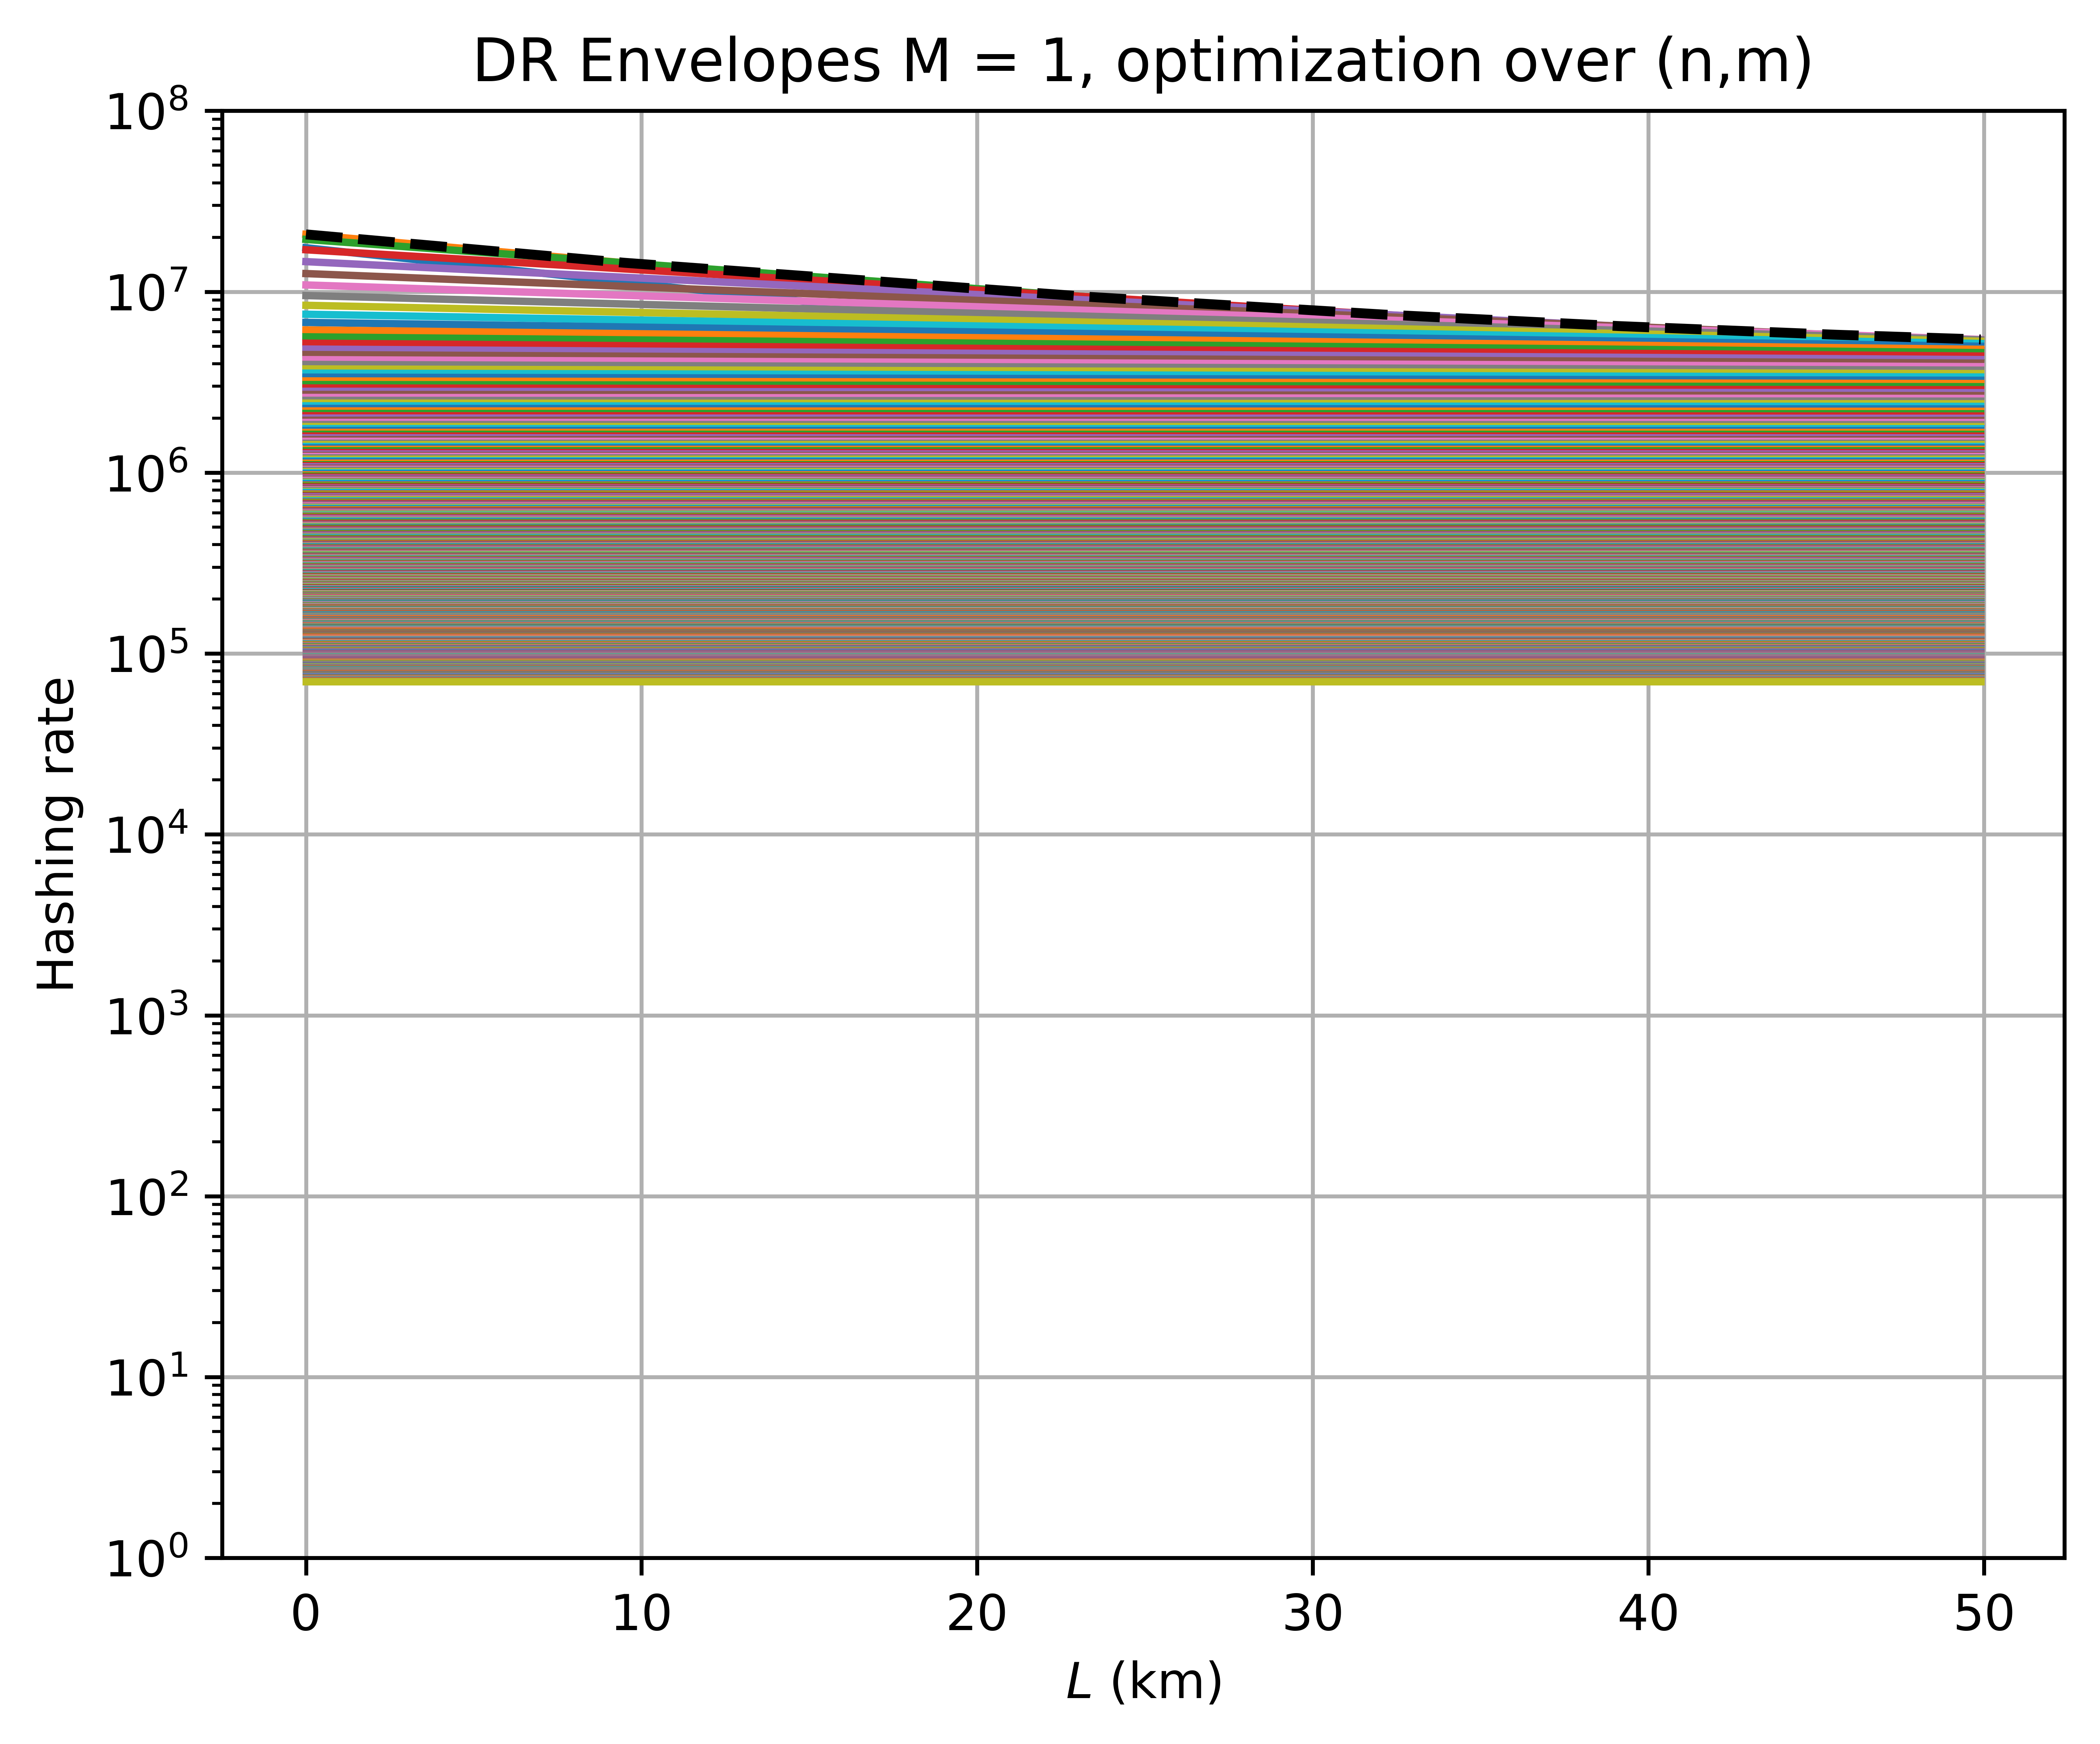

In [ ]:
fig, ax = plt.subplots(figsize=(6,5), dpi=1000)

ax.set_yscale("log")
ax.set_title("DR Envelopes M = 1, optimization over (n,m)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom=1e0, top=1e8)
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

# plot per-m envelopes
for i, env in enumerate(dr_envs):
    ax.plot(
        Ls,
        env,
        color=color_cycle(i % 10),
        linestyle="-",
        label=f"M = 1, m = {m_values[i]}"
    )

# plot fully maximized envelope
ax.plot(
    Ls,
    fully_maximized_env,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Maximized over n,m"
)

# ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# PLOB Bound

In [57]:
def PLOB_bound(L, alpha_dB_per_km=0.2 , M = 1 , tau = 1e-8):
    eta = np.exp(-alpha_dB_per_km * L)
    return -np.log2(1 - eta) * (M / tau)

Ls = np.arange(0,50,0.1)
PLOB_bound_tab = []
for L in Ls:
    PLOB_bound_tab.append(PLOB_bound(L))

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_19198/655112157.py:3: RuntimeWarning: divide by zero encountered in log2
  return -np.log2(1 - eta) * (M / tau)


# All plots together

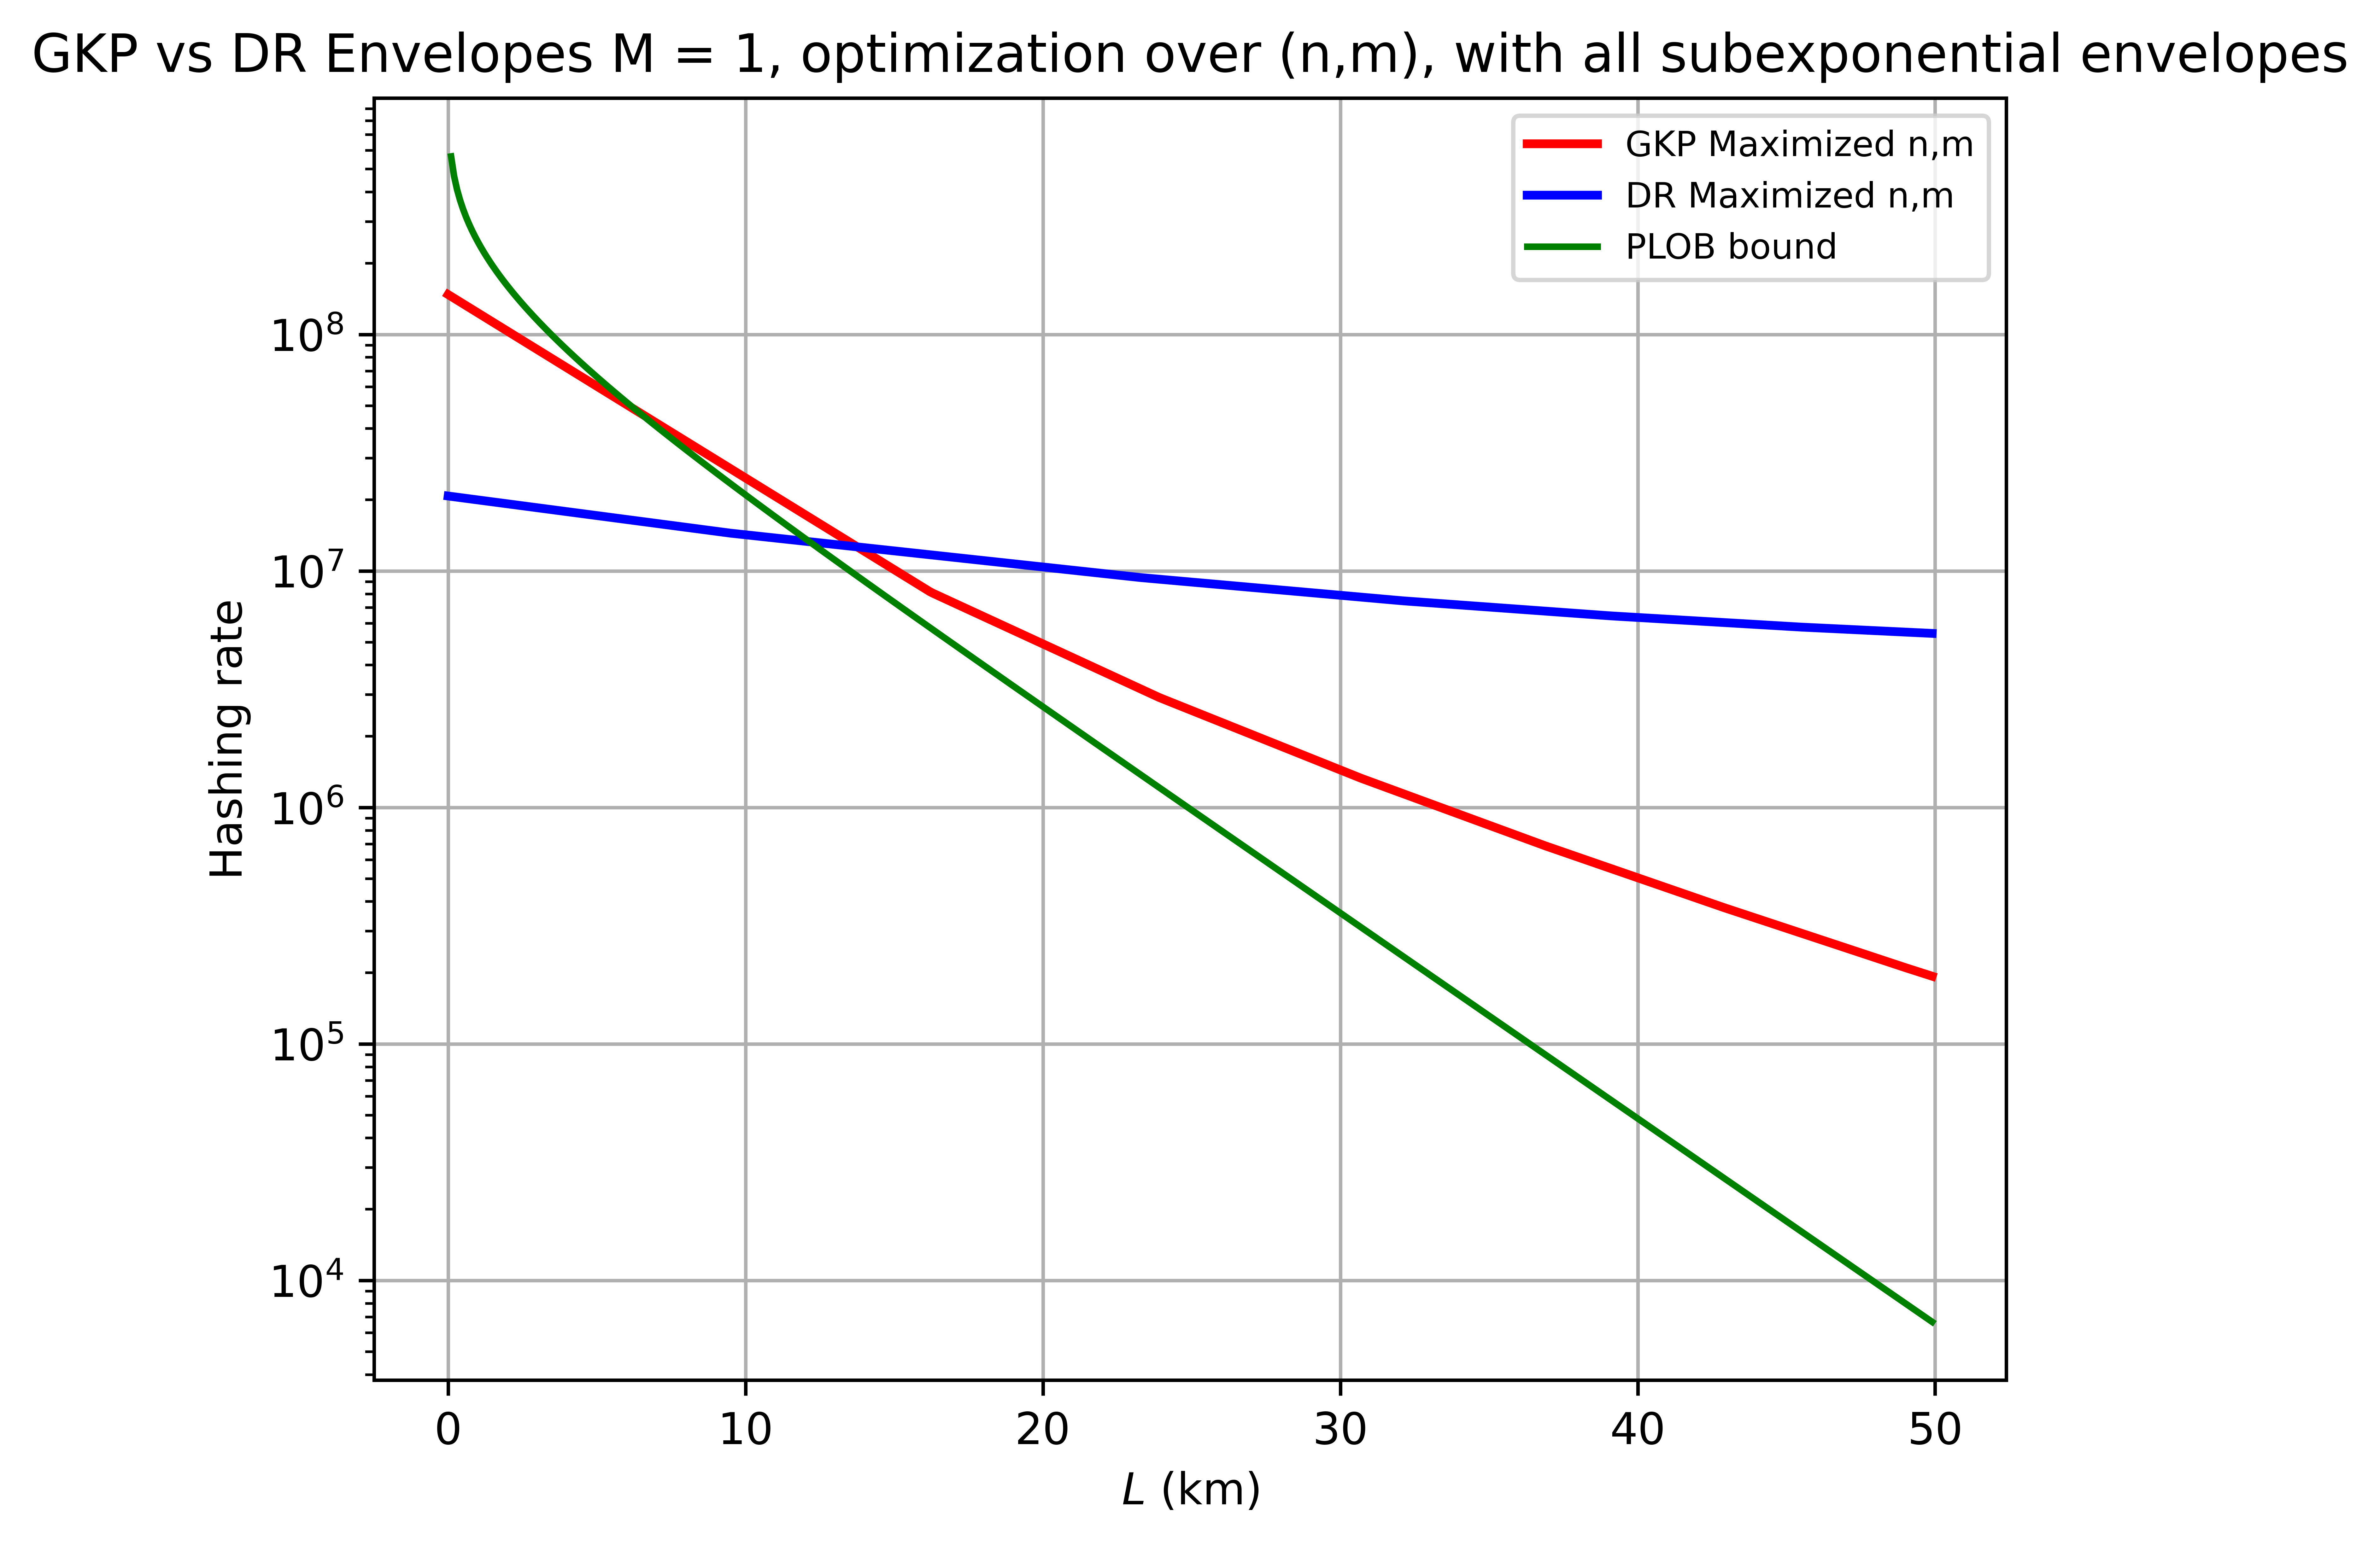

In [58]:
fig, ax = plt.subplots(figsize=(6,5), dpi=1000)

ax.set_yscale("log")
ax.set_title("GKP vs DR Envelopes M = 1, optimization over (n,m), with all subexponential envelopes")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

# fully maximized GKP envelope over n,m
ax.plot(
    Ls,
    fully_maximized_gkp_env,
    color="red",
    linestyle="-",
    linewidth=2,
    label="GKP Maximized n,m"
)

# fully maximized DR envelope over n,m
ax.plot(
    Ls,
    fully_maximized_env,
    color="blue",
    linestyle="-",
    linewidth=2,
    label="DR Maximized n,m"
)

ax.plot(Ls,PLOB_bound_tab , color='green',label="PLOB bound")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# GKP qudit code

# Qudit basis definition

In [59]:
#defining basic qudit vectors
def qudit_basis(d , k):
    vec = np.zeros((d , 1) , dtype = complex)
    vec[k , 0] = 1.0
    return vec

# Qudit Bell State

# $|\Psi_{k,l}\rangle_{1,2} = \frac{1}{\sqrt{d}}\sum_{k'=0}^{d-1}exp(2\pi i k' l /d) |k'\rangle_{1} \otimes |k' - k\rangle_{2}$

In [60]:
#defining the qudit Bell state from Equation (26)
#in the published manuscript this comes from Equatoin (S3) in the Supplemental Material
def qudit_Bell_state(d , k , l):
    #above expression is a summation so we initialise a 0-vector and iteratively add to it
    psi = np.zeros((d * d , 1) , dtype = complex)

    #iterating over index r = k'
    for r in range(d):

        phase = np.exp(2j * np.pi * r * l / d)
        ket1 = qudit_basis(d , r)
        ket2 = qudit_basis(d , (r - k) % d)

        psi += phase * kron(ket1 , ket2)

    return psi / np.sqrt(d)

#defining qudit Bell state projector
def qudit_Bell_state_projector(d , k , l):
    psi = qudit_Bell_state(d , k , l)
    return psi @ np.conjugate(psi.T)

# Loss Model from QR model

In [61]:
# transmissivity for QR setup
def new_eta(L, n):
    alpha_dB_per_km = 0.2
    # convert dB/km to 1/km
    alpha = (alpha_dB_per_km / 10) * np.log(10)
    # eta ∈ [0, 1]
    return np.exp(-alpha * L / (n + 1))

#Quality of GKP state
def sigma_loss(sigma , L , n):
    eta = new_eta(L , n)
    # subjecting qudits to pure loss channel
    return np.sqrt(eta * sigma**2 + (1 - eta))

# Shift Probability

# $P^{(sq)}(\hat{X}^{k},\sigma^{2}) \equiv P^{(sq)}(\hat{Z}^{k},\sigma^{2})$

## $P^{(sq)}(\hat{X}^{k},\sigma^{2}) = P^{(sq)}(\hat{Z}^{k},\sigma^{2}) = \sum_{j \in \mathbb{Z}} \frac{1}{2} \Big(\text{erf}\Big(\sqrt{\frac{2\pi}{d}} \frac{jd + k + 1/2}{\sigma}\Big) - \text{erf}\Big(\sqrt{\frac{2\pi}{d}} \frac{jd + k - 1/2}{\sigma}\Big)\Big)$

In [62]:
from scipy.special import erf

def shift_probability(d , k , sigma , j_cutoff = 30):

    #considering the scenario of an ideal-squeezed GKP qudit
    if sigma == 0:
        return 1.0 if k == 0 else 0.0

    #this probability is a summation over the integers
    #we will not consider an infinite summation,
    #instead we consider a portion of the space denoted j_cutoff
    #since this probability is a summation we begin with an initialisation
    shift_probability_total = 0.0

    #defining the qudit lattice spacing
    qudit_lattice_spacing = np.sqrt(2 * np.pi / d)

    #summing over the space defined by j_cutoff
    for j in range(-j_cutoff , j_cutoff + 1):
        upper_bound = qudit_lattice_spacing * (j * d + k + 0.5) / sigma
        lower_bound = qudit_lattice_spacing * (j * d + k - 0.5) / sigma
        shift_probability_total += 0.5 * (erf(upper_bound) - erf(lower_bound))
    
    return float(np.real(shift_probability_total))

In the definition of our memory-memory state

## $\tilde{\rho}_{\textbf{M}_{1}\textbf{M}_{2}} = \sum_{k_{1},k_{2} = 0}^{d-1} P_{shift}^{(k_{1},k_{2})}(\sigma^{2})|\Psi_{k',l'}\rangle\langle\Psi_{k',l'}|_{\textbf{M}_{1}\textbf{M}_{2}}$

with 

## $P_{shift}^{(k_{1},k_{2})}(\sigma^{2}) = P^{(sq)}(\hat{X}^{k_{1}},\sigma^{2})\cdot P^{(sq)}(\hat{Z}^{k_{1}},\sigma^{2})$

the shift probabilities are defined by a summation over $k_{1}k_{2}=0$ up to $d-1$, so we take the above script for the shift probability and we sum up over all $k$ from 0 up to $d-1$. Later when we define the memory-memory state we will input the different shift errors ($\hat{X}$,$\hat{Z}$)

In [63]:
def shift_probability_vector(d , sigma , j_cutoff = 30):
    #for each value of k over which we are performing our summation
    #we create an array d elements long with each entry being the probability calculated for said value k
    #we then normalise these probabilities by dividing by the sum of shift_probabilities
    #we normalise because in our defintiion of shift_probability we truncate the space we're observing using j_cutoff
    #the summation is performed in the next cell
    shift_probabilities = np.array([shift_probability(d , k , sigma , j_cutoff) for k in range(d)])
    
    # defining the total probability vector of length d
    total = np.sum(shift_probabilities)
    if total <= 0:
        raise ValueError("Shift probability normalisation failed")

    return shift_probabilities / total

# Building $\tilde{\rho}_{\textbf{M}_{1}\textbf{M}_{2}}$

Now we construct our memory-memory state $|\Psi_{k' , l'}\rangle\langle\Psi_{k' , l'}|_{\textbf{M}_{1}\textbf{M}_{2}}$

We note that the qudit Bell state we have constructed $|\Psi_{k' , l'}\rangle_{\textbf{M}_{1}\textbf{M}_{2}}$ is defined using the unshifted state $|\Psi_{0,0}\rangle_{M_{i}G_{i}}$ (no $\hat{X}$ or $\hat{Z}$ errors) subjected to the Weyl operators $W_{1}^{(0 , d-x_{L})}W_{2}^{(d - y_{L} , 0)}$:

$|\Psi_{k' , l'}\rangle_{\textbf{M}_{1}\textbf{M}_{2}} = W_{1}^{(0 , d-x_{L})}W_{2}^{(d - y_{L} , 0)} |\Psi_{0,0}\rangle_{M_{i}G_{i}}$

We note that this $|\Psi_{k' , l'}\rangle_{\textbf{M}_{1}\textbf{M}_{2}}$ state is dependent on the BSM logical outcomes $(x_{L} , y_{L})$, where the labels of the qudit Bell state $\textbf{AFTER}$ the DHD are described as

$k' = d - x_{L}$ (mod d) and $l' = d - y_{L}$ (mod d)

In [64]:
def qudit_memory_memory_state(d , sigma , j_cutoff = 30 , xL = 0 , yL = 0):

    #we first define shift probabilities for X and Z errors
    
    P_shift_X = shift_probability_vector(d , sigma , j_cutoff)
    P_shift_Z = shift_probability_vector(d , sigma , j_cutoff)

    #we also define state labels dependent on the logical outcomes of the BSM xL and yL
    #these labels (xL , yL) tell us which Bell state we get from the measurement
    #since we know them  we can always correct them
    #therefore we set xL = yL = 0 without loss of generality
    
    k0 = (d - xL) % d
    l0 = (d - yL) % d

    #initialising our memory-memory state
    rho = np.zeros((d * d , d * d) , dtype = complex)

    #X shift occurs k1 times
    #Z shift occurs k2 times
    for k1 in range(d):
        for k2 in range(d):
            #defining the full shift probability for X and Z errors
            shift_probability = P_shift_X[k1] * P_shift_Z[k2]
            #defining the k and l labels for the memory-memory state
            #these are the labels defined in qudit_Bell_state_projector
            #they need to be shifted due to the X and Z errors that occur
            k_label = (k0 + k1) % d
            l_label = (l0 + k2) % d
            #summing over labels to obtain memory-memory state
            rho += shift_probability * qudit_Bell_state_projector(d , k_label , l_label)

    return rho

# Defining the Bell diagonal form of the GKP qudit state

In [65]:
def qudit_bell_diagonal_probs(d, sigma, xL=0, yL=0, j_cutoff=30):
    ProbX = shift_probability_vector(d, sigma, j_cutoff)
    ProbZ = shift_probability_vector(d, sigma, j_cutoff)

    k0 = (d - xL) % d
    l0 = (d - yL) % d

    probs = {}

    for k1 in range(d):
        for k2 in range(d):
            k_label = (k0 + k1) % d
            l_label = (l0 + k2) % d
            probs[(k_label, l_label)] = ProbX[k1] * ProbZ[k2]

    return probs

# Loss Model from GKP qudit paper

In [66]:
# ----------------------------
# Loss + squeezing model
# ----------------------------

def sigma_squared_from_squeezing_db(squeezing_db):

    # eta_squeeze = -10 log10(sigma^2)
    # so sigma^2 = 10^(-eta_squeeze/10).

    if np.isinf(squeezing_db):
        return 0.0
    return 10** (-squeezing_db / 10)


def half_channel_transmissivity(loss_db):

    # x-axis is loss of half channel in dB.
    # eta_half_channel_loss = sqrt(eta) = 10^(-loss_db / 10).

    return 10**(-loss_db / 10)


def effective_sigma(loss_db , squeezing_db):

    # Paper states converison model:
    # sigma_i^2 -> sigma_i^2 + (1 - sqrt(eta))

    # Here sqrt(eta) is the half-channel transmissivity.

    eta = half_channel_transmissivity(loss_db)
    sigma_i_squared = sigma_squared_from_squeezing_db(squeezing_db)
    sigma_eff_squared = sigma_i_squared + (1 - eta)
    return np.sqrt(sigma_eff_squared)

# Hashing Bound calculation

In [67]:
# ----------------------------
# Hashing bound from Eq. (18) of published manuscript
# ----------------------------

def hashing_bound_qudit(d , sigma , j_cutoff = 30):
    ProbX = shift_probability_vector(d , sigma , j_cutoff)
    ProbZ = shift_probability_vector(d , sigma , j_cutoff)

    Prob = np.outer(ProbX , ProbZ)
    Prob = Prob[Prob > 0]

    return np.log2(d) + np.sum(Prob * np.log2(Prob))


def hashing_bound_vs_loss(N , loss_db_array , squeezing_db):
    d = 2 ** N
    rates = []

    for loss_db in loss_db_array:
        sigma_eff = effective_sigma(loss_db , squeezing_db)
        rate = hashing_bound_qudit(d , sigma_eff)
        rates.append(max(rate , 0.0))

    return np.array(rates)


def repeaterless_bound_half_channel(loss_db_array):
    """
    Paper compares to -log2(1 - sqrt(eta)).
    Here sqrt(eta) = half-channel transmissivity.
    """
    eta = half_channel_transmissivity(loss_db_array)
    return -np.log2(1 - eta)

# Recreation of Fig. 4(a) from "Entangling Quantum Memories at Channel Capacity"

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_19198/2107881734.py:33: RuntimeWarning: divide by zero encountered in log2
  return -np.log2(1 - eta)


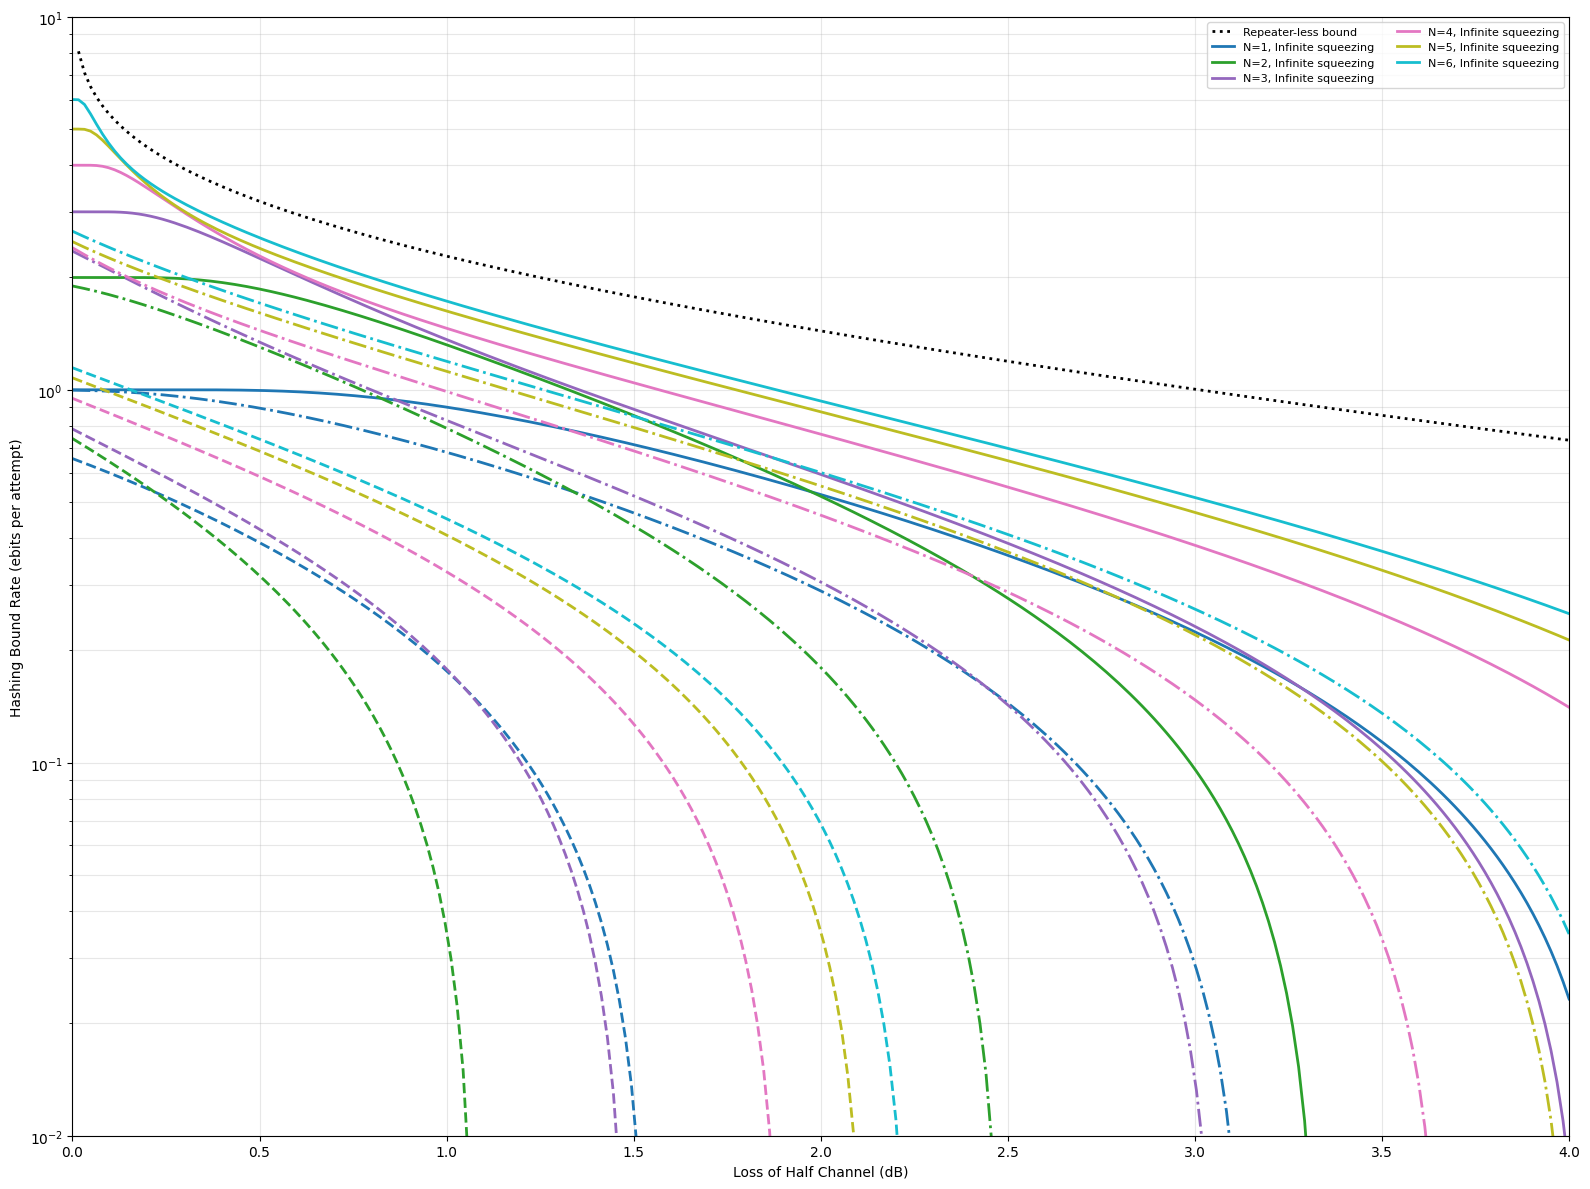

In [68]:
# ----------------------------
# Reproduce Fig. 4a: square GKP
# ----------------------------

def plot_fig4a_square_gkp():
    loss_db = np.linspace(0.0, 4.0, 250)

    Ns = [1, 2, 3, 4, 5, 6]
    squeezing_cases = [
        (np.inf, "-", "Infinite squeezing"),
        (10, "-.", "10 dB"),
        (5, "--", "5 dB")
    ]

    plt.figure(figsize=(16 , 12))

    # Repeaterless bound
    plt.semilogy(
        loss_db,
        repeaterless_bound_half_channel(loss_db),
        "k:",
        linewidth=2,
        label="Repeater-less bound"
    )

    colors = plt.cm.tab10(np.linspace(0, 1, len(Ns)))

    for idx, N in enumerate(Ns):
        for squeezing_db, linestyle, squeeze_label in squeezing_cases:
            rates = hashing_bound_vs_loss(
                N,
                loss_db,
                squeezing_db
            )

            label = f"N={N}, {squeeze_label}" if squeezing_db == np.inf else None

            plt.semilogy(
                loss_db,
                rates,
                linestyle=linestyle,
                color=colors[idx],
                linewidth=2,
                label=label
            )

    plt.xlabel("Loss of Half Channel (dB)")
    plt.ylabel("Hashing Bound Rate (ebits per attempt)")
    plt.xlim(0, 4)
    plt.ylim(1e-2, 1e1)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


plot_fig4a_square_gkp()

There is a mismatch between this plot and Fig. 4(a) from Prajit's paper, this may be due to modelling truncation in the simulations

# Building non-deterministic DHD for GKP qudit swap

# Defining the Gaussian

In [69]:
def homodyne_distribution(x , mu , sigma , L , n):
    sigma = sigma_loss(sigma , L , n)
    return (
        np.exp(-(x - mu)**2 / (2 * sigma**2))
        /
        (sigma * np.sqrt(2*np.pi))
    )

# Probability of correctly interpreting the measurement outcome

In [70]:
def Pc_qudit(d , sigma , nu , L , n , j_cutoff = 30):

    qudit_lattice_spacing = np.sqrt(2 * np.pi / d)

    total = 0.0

    for j in range(-j_cutoff , j_cutoff + 1):

        lower = qudit_lattice_spacing * (j * d - 0.5) + nu
        upper = qudit_lattice_spacing * (j * d + 0.5) - nu

        integrand = lambda x: homodyne_distribution(x , 0 , sigma , L , n)

        total += quad(integrand , lower , upper)[0]

    return total

# Probability of incorrectly interpreting the measurement outcome

In [71]:
def Pf_qudit(d , sigma , nu , L , n , j_cutoff = 30):

    qudit_lattice_spacing = np.sqrt(2 * np.pi / d)

    total = 0.0

    for k in range(1 , d):

        for j in range(-j_cutoff , j_cutoff + 1):

            lower = (qudit_lattice_spacing * (j * d + k - 0.5) + nu)
            upper = (qudit_lattice_spacing * (j * d + k + 0.5) - nu)

            integrand = lambda x: homodyne_distribution(x , 0 , sigma , L , n)

            total += quad(integrand , lower , upper)[0]

    return total

# Defining the shift probabilities as the interpretation of $\textbf{any}$ measurement outcome such that $P_{\text{shift}} = P_{c} + P_{f} = \sum_{k=0}^{d} P^{k}$

In [72]:
def shift_probability(d , k , sigma , nu , L , n , j_cutoff = 30):

    qudit_lattice_spacing = np.sqrt(2 * np.pi / d)

    total = 0.0

    for j in range(-j_cutoff , j_cutoff + 1):

        lower = (qudit_lattice_spacing * (j * d + k - 0.5) + nu)
        upper = (qudit_lattice_spacing * (j * d + k + 0.5) - nu)

        integrand = lambda x: homodyne_distribution(x , 0 , sigma , L , n)

        total += quad(integrand , lower , upper)[0]

    return total

In [73]:
def shift_probability_vector(d , sigma , nu , L , n , j_cutoff = 30):

    probs = np.array([
        shift_probability(d , k , sigma , nu , L , n , j_cutoff)
        for k in range(d)
    ])

    total = np.sum(probs)

    if total <= 0:
        raise ValueError(
            "Shift probability normalization failed"
        )

    return probs / total

# Using new definition of $P_{\text{shift}}$ to define Bell-diagonal representation of memory-memory qudit state

In [74]:
def qudit_bell_diagonal_prob_table(d , sigma , nu , L , n , xL = 0 , yL = 0 , j_cutoff = 30):

    ProbX = shift_probability_vector(d , sigma , nu , L , n , j_cutoff)
    ProbZ = shift_probability_vector(d , sigma , nu , L , n , j_cutoff)

    P_error = np.outer(ProbX , ProbZ)
    k0 = (d - xL) % d
    l0 = (d - yL) % d

    P_bell = np.roll(P_error , shift = (k0 , l0) , axis = (0 , 1))

    return P_bell

In [75]:
def qudit_memory_memory_state(d , sigma , nu , L , n , xL = 0 , yL = 0 , j_cutoff = 30):

    P_bell = qudit_bell_diagonal_prob_table(d , sigma , nu , L , n , xL , yL , j_cutoff)
    rho = np.zeros((d * d , d * d) , dtype = complex)

    for k in range(d):
        for l in range(d):
            rho += (P_bell[k,l] * qudit_Bell_state_projector(d , k , l))
    return rho

In [ ]:
def qudit_hashing_bound(P_bell):

    d = P_bell.shape[0]
    P = P_bell[P_bell > 0]

    return max(0.0 , np.log2(d) + np.sum(P * np.log2(P)))

# Bell diagonal Map for GKP qudits

We now consider some probability $P[k , l]$ that  a Bell pair has Weyl error label $P[k , l] = \hat{X}^{k}\hat{Z}^{l}$, similarly, we consider another Bell pair mixture $Q[k , l]$. When we perform a QR swap and combine the Bell pairs we need to combine the Weyl labels which is exactly how our Bell-twirlled map rNtimes previously worked.

However, in the qubit case, our operators combine adition modulo 2:
$\hat{X}\hat{X} = \hat{\mathbb{I}}$
$\hat{Z}\hat{Z} = \hat{\mathbb{I}}$
effectively, 1 + 1 = 0 (mod 2)

For qudits,
$\hat{X}^{a}\hat{X}^{b} = \hat{X}^{(a + b)}$   (mod d)
$\hat{Z}^{a}\hat{Z}^{b} = \hat{Z}^{(a + b)}$   (mod d)

Therefore, if one link has label $(k_{1} , l_{1})$ and the other $(k_{2} , l_{2})$, then after a BSM swap the resulting label is $(k_{1} + k_{2} , l_{1} + l_{2})$ (mod d). So to effectively model the combination of two Bell-diagonal vectors we need an operation of the following form:

$R(k , l) = \sum_{a , b} P(a , b)Q(k - a , l - b)$

$\textbf{The convolution theorem states "\textit{convolution in real space = multiplication in Fourier space}}$

So rather than looping over

    for k in range(d):

        for l in range (d):

            total = 0.0

            for a in range(d):
                
                for b in range(d):

                    total += (P[a , b] * Q[(k - a) % d , (l - b) % d])

        R[k , l] = total

    return R

We insted use Fourier transforms, where np.fft.fft2(P) computers the 2D discrete Fourier transform of the probability table, allowing us to move from $P(k , l)$ to $\tilde{P}(\omega_{k} , \omega{l})$.

So when we compute

np.fft.fft2(P) * np.fft.fft2(Q) = $\tilde{P Q}$ because $\mathcal{F}(P * Q) = \mathcal{F}(P)\mathcal{F}(Q)$ so $\mathcal{P} * \mathcal{Q} = \mathcal{F}^{-1}[\mathcal{F}(P)\mathcal{F}(Q)]$

and we can compute the inverse Fourier transform np.fft.ifft2(...) to return us back to probability space, thus obtaining $R = PQ$

In [76]:
def qudit_bell_swap_convolution(P, Q):

    R = np.fft.ifft2(np.fft.fft2(P) * np.fft.fft2(Q))

    R = np.real_if_close(R)
    R = np.real(R)

    R = np.clip(R , 0.0 , None)

    R = R / np.sum(R)

    return R

In [77]:
def qudit_chain_distribution(P_succ , n):

    P_chain = np.fft.ifft2(np.fft.fft2(P_succ)** (n + 1))
    P_chain = np.real_if_close(P_chain)
    P_chain = np.real(P_chain)

    P_chain = np.clip(P_chain , 0.0 , None)

    P_chain = P_chain / np.sum(P_chain)

    return P_chain

# GKP qudit Hashing Rate calculation

In [78]:
def qudit_hashing_rate(Nreg , squeezing_db , nu , L , n, M , q , tau , m , j_cutoff = 30 , loss_model="preamplified"):

    d = 2 ** Nreg

    # elementary-link half-channel loss
    half_loss_db = (0.2 * L / (2*(n + 1)))

    sigma_eff = effective_sigma(half_loss_db , squeezing_db , loss_model = loss_model)

    Pc = Pc_qudit(d , sigma_eff , nu , L , n , j_cutoff)
    Pf = Pf_qudit(d , sigma_eff , nu , L , n , j_cutoff)

    pSWAP = (Pc + Pf)**2
    pELEM = (1 - (1 - pSWAP)**(M * m))
    pNETWORK = (pELEM**(n + 1) * q**n)
    rate = (pNETWORK / (tau * m))

    P_elem = qudit_bell_diagonal_prob_table(d ,sigma_eff , nu , L , n , j_cutoff = j_cutoff)

    P_chain = qudit_chain_distribution(P_elem , n)

    state_bound = qudit_hashing_bound(P_chain)

    return rate * state_bound

# Optimsied Hashing Rate

In [79]:
def optimal_qudit_hashing_rate(Nreg , squeezing_db , L , n , M , q , tau , m , j_cutoff = 30 , loss_model = "preamplified" , return_nu = False):

    d = 2 ** Nreg

    spacing = np.sqrt(2*np.pi / d)

    def neg_rate(nu):

        try:
            value = qudit_hashing_rate(Nreg , squeezing_db , nu , L , n , M , q , tau , m , j_cutoff , loss_model)

            return -value if value > 0 else np.inf

        except Exception:
            return np.inf

    result = minimize_scalar(
        neg_rate,
        bounds=(0, spacing / 2),
        method='bounded'
    )

    rate = -result.fun

    if not np.isfinite(rate) or rate <= 0:
        rate = 0.0

    if return_nu:
        return rate , result.x

    return rate

# GKP Qudit analysis

# Half-Channel loss

In [114]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.linalg import eigvalsh
from scipy.stats import linregress
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helpers: loss + squeezing
# -------------------------------------------------

def sigma_squared_from_squeezing_db(squeezing_db):
    if np.isinf(squeezing_db):
        return 0.0
    return 10 ** (-squeezing_db / 10)

def half_channel_transmissivity(loss_db):
    # loss_db is the half-channel loss in dB
    return 10 ** (-loss_db / 10)

def effective_sigma(loss_db, squeezing_db, loss_model="preamplified"):
    eta = half_channel_transmissivity(loss_db)
    sigma2 = sigma_squared_from_squeezing_db(squeezing_db)

    if loss_model == "preamplified":
        sigma2_eff = sigma2 * eta + (1 - eta)
    elif loss_model in {"cc", "cc-amplification"}:
        sigma2_eff = sigma2 + (1 - eta) / (2 * eta)
    else:
        raise ValueError("loss_model must be 'preamplified' or 'cc'")

    return np.sqrt(sigma2_eff)

# -------------------------------------------------
# Qudit Bell-diagonal model
# -------------------------------------------------

def qudit_basis(d, k):
    vec = np.zeros((d, 1), dtype=complex)
    vec[k, 0] = 1.0
    return vec

def qudit_Bell_state(d, k, l):
    psi = np.zeros((d * d, 1), dtype=complex)
    for r_ in range(d):
        phase = np.exp(2j * np.pi * r_ * l / d)
        ket1 = qudit_basis(d, r_)
        ket2 = qudit_basis(d, (r_ - k) % d)
        psi += phase * kron(ket1, ket2)
    return psi / np.sqrt(d)

def qudit_Bell_state_projector(d, k, l):
    psi = qudit_Bell_state(d, k, l)
    return psi @ psi.conj().T

def homodyne_distribution(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

def Pc_qudit(d, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for j in range(-j_cutoff, j_cutoff + 1):
        lower = a * (j * d - 0.5) + nu
        upper = a * (j * d + 0.5) - nu
        total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def Pf_qudit(d, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for k in range(1, d):
        for j in range(-j_cutoff, j_cutoff + 1):
            lower = a * (j * d + k - 0.5) + nu
            upper = a * (j * d + k + 0.5) - nu
            total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def shift_probability(d, k, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for j in range(-j_cutoff, j_cutoff + 1):
        lower = a * (j * d + k - 0.5) + nu
        upper = a * (j * d + k + 0.5) - nu
        total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def shift_probability_vector(d, sigma, nu, j_cutoff=30):
    probs = np.array([shift_probability(d, k, sigma, nu, j_cutoff) for k in range(d)], dtype=float)
    total = np.sum(probs)
    if total <= 0 or not np.isfinite(total):
        raise ValueError("Shift probability normalisation failed")
    return probs / total

def qudit_bell_diagonal_prob_table(d, sigma, nu, xL=0, yL=0, j_cutoff=30):
    ProbX = shift_probability_vector(d, sigma, nu, j_cutoff)
    ProbZ = shift_probability_vector(d, sigma, nu, j_cutoff)

    P_error = np.outer(ProbX, ProbZ)
    k0 = (d - xL) % d
    l0 = (d - yL) % d
    return np.roll(P_error, shift=(k0, l0), axis=(0, 1))

def qudit_hashing_bound(P_bell):
    d = P_bell.shape[0]
    P = P_bell[P_bell > 0]
    return max(0.0, np.log2(d) + np.sum(P * np.log2(P)))

def qudit_chain_distribution(P_succ, n):
    P_chain = np.fft.ifft2(np.fft.fft2(P_succ) ** (n + 1))
    P_chain = np.real_if_close(P_chain)
    P_chain = np.real(P_chain)
    P_chain = np.clip(P_chain, 0.0, None)
    P_chain = P_chain / np.sum(P_chain)
    return P_chain

def qudit_hashing_rate(Nreg, squeezing_db, nu, L, n, M, q, tau, m, j_cutoff=30, loss_model="preamplified"):
    d = 2 ** Nreg

    half_loss_db = 0.2 * L / (2 * (n + 1))
    sigma_eff = effective_sigma(half_loss_db, squeezing_db, loss_model=loss_model)

    Pc = Pc_qudit(d, sigma_eff, nu, j_cutoff=j_cutoff)
    Pf = Pf_qudit(d, sigma_eff, nu, j_cutoff=j_cutoff)

    pSWAP = (Pc + Pf) ** 2
    pELEM = 1 - (1 - pSWAP) ** (M * m)
    pNETWORK = (pELEM ** (n + 1)) * q**n
    rate = pNETWORK / (tau * m)

    P_elem = qudit_bell_diagonal_prob_table(d, sigma_eff, nu, j_cutoff=j_cutoff)
    P_chain = qudit_chain_distribution(P_elem, n)
    state_bound = qudit_hashing_bound(P_chain)

    return rate * state_bound

def optimal_qudit_hashing_rate(Nreg, squeezing_db, L, n, M, q, tau, m, j_cutoff=30, loss_model="preamplified", return_nu=False):
    d = 2 ** Nreg
    spacing = np.sqrt(2 * np.pi / d)

    def neg_rate(nu):
        try:
            value = qudit_hashing_rate(Nreg, squeezing_db, nu, L, n, M, q, tau, m, j_cutoff, loss_model)
            return -value if value > 0 else np.inf
        except Exception:
            return np.inf

    result = minimize_scalar(neg_rate, bounds=(0, spacing / 2), method="bounded")
    rate = -result.fun
    if not np.isfinite(rate) or rate <= 0:
        rate = 0.0

    if return_nu:
        return rate, result.x
    return rate

In [115]:
Ls = np.arange(0, 150, 1.5)

# d = 2 corresponds to Nreg = 1
Nreg = 1

# Match your old qubit sigma^2 = 0.01
squeezing_db = 20

M = 1
q = 0.7
tau = 1e-8
m = 10

rates1q  = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 1,  M, q, tau, m, loss_model="preamplified") for L in Ls]
rates2q  = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 2,  M, q, tau, m, loss_model="preamplified") for L in Ls]
rates4q  = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 4,  M, q, tau, m, loss_model="preamplified") for L in Ls]
rates8q  = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 8,  M, q, tau, m, loss_model="preamplified") for L in Ls]
rates16q = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 16, M, q, tau, m, loss_model="preamplified") for L in Ls]

/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_19198/1790293195.py:30: RuntimeWarning: divide by zero encountered in log
  log_env = np.log(rate_envelope)
/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


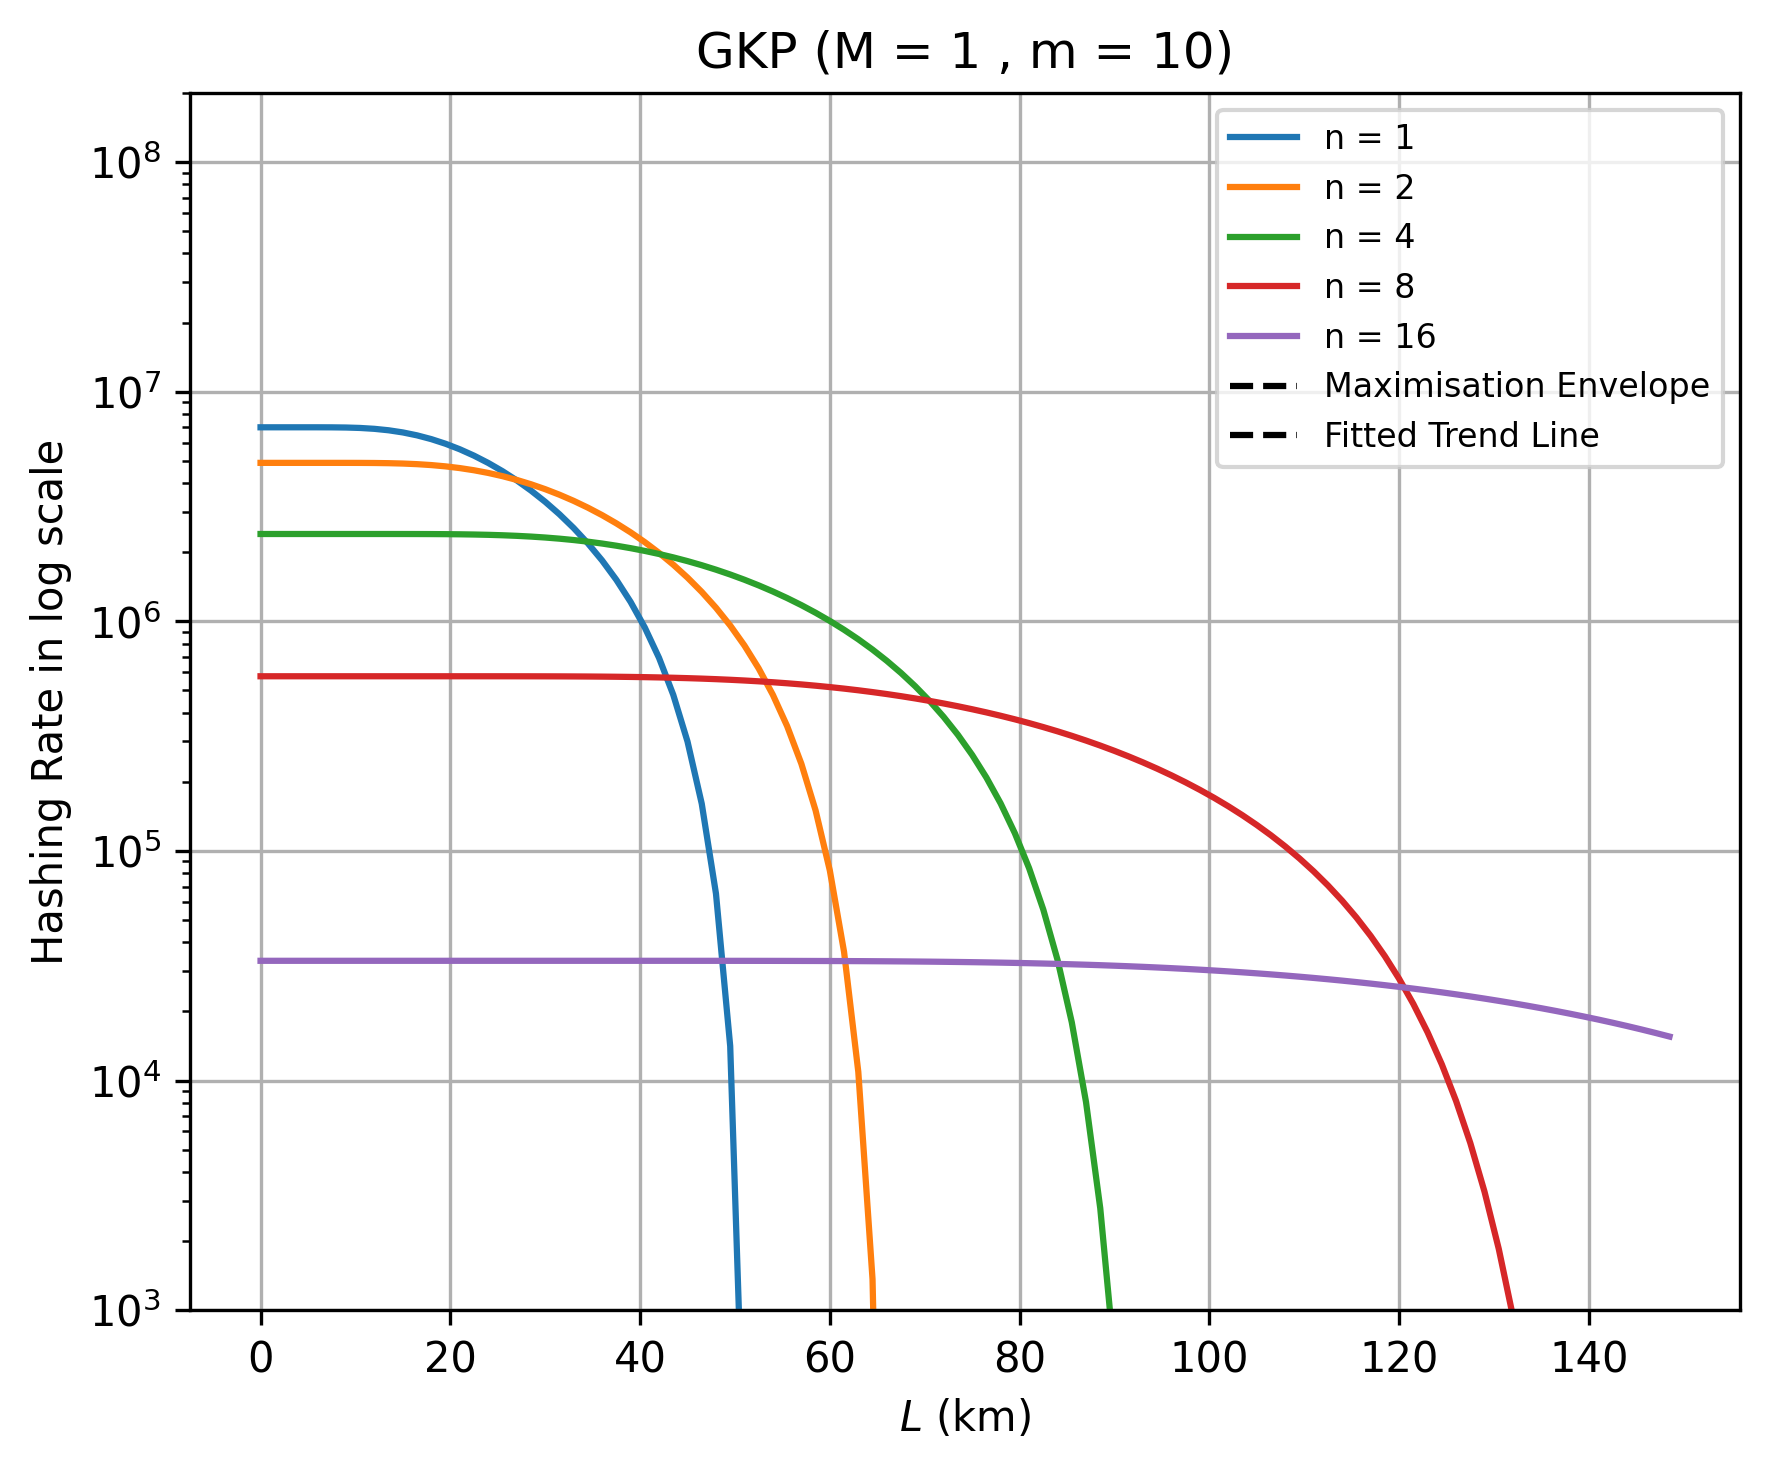

In [116]:
fig, ax = plt.subplots(figsize=(6, 5),dpi = 300)
ax.set_yscale("log")
ax.set_title("GKP (M = 1 , m = 10)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=2e8)
ax.grid(True)

n_vals = [1 , 2 , 4 , 8 , 16]
Ls = np.array(Ls)  # ensure it's an array
gkp_list = [rates1q , rates2q , rates4q , rates8q , rates16q]

color_cycle = plt.get_cmap("tab10")

for i, rate_curve in enumerate(gkp_list):
    n = n_vals[i]
    color = color_cycle(i)
    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)

n_scan_vals = np.arange(1 , 17)
rate_envelope = []
for L in Ls:
    best_rate = 0.0
    for n in n_scan_vals:
        rate = optimal_qudit_hashing_rate(Nreg , squeezing_db , L , n , M , q , tau , m , loss_model = "preamplified")
    rate_envelope.append(best_rate)
rate_envelope = np.array(rate_envelope)
ax.plot(Ls, rate_envelope, color="black", linestyle="--", linewidth=1.5, label="Maximisation Envelope")

log_env = np.log(rate_envelope)
fit_mask = (Ls > 10) & (Ls < 100)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env = np.exp(slope * Ls + intercept)

ax.plot(Ls, predicted_env, color="black", linestyle="--", label="Fitted Trend Line")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Full Channel loss

In [ ]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.linalg import eigvalsh
from scipy.stats import linregress
import matplotlib.pyplot as plt

# -------------------------------------------------
# Helpers: loss + squeezing
# -------------------------------------------------

def sigma_squared_from_squeezing_db(squeezing_db):
    if np.isinf(squeezing_db):
        return 0.0
    return 10 ** (-squeezing_db / 10)

def half_channel_transmissivity(loss_db):
    # loss_db is the half-channel loss in dB
    return 10 ** (-loss_db / 10)

def effective_sigma(loss_db, squeezing_db, loss_model="preamplified"):
    eta = half_channel_transmissivity(loss_db)
    sigma2 = sigma_squared_from_squeezing_db(squeezing_db)

    if loss_model == "preamplified":
        sigma2_eff = sigma2 * eta + (1 - eta)
    elif loss_model in {"cc", "cc-amplification"}:
        sigma2_eff = sigma2 + (1 - eta) / (2 * eta)
    else:
        raise ValueError("loss_model must be 'preamplified' or 'cc'")

    return np.sqrt(sigma2_eff)

# -------------------------------------------------
# Qudit Bell-diagonal model
# -------------------------------------------------

def qudit_basis(d, k):
    vec = np.zeros((d, 1), dtype=complex)
    vec[k, 0] = 1.0
    return vec

def qudit_Bell_state(d, k, l):
    psi = np.zeros((d * d, 1), dtype=complex)
    for r_ in range(d):
        phase = np.exp(2j * np.pi * r_ * l / d)
        ket1 = qudit_basis(d, r_)
        ket2 = qudit_basis(d, (r_ - k) % d)
        psi += phase * kron(ket1, ket2)
    return psi / np.sqrt(d)

def qudit_Bell_state_projector(d, k, l):
    psi = qudit_Bell_state(d, k, l)
    return psi @ psi.conj().T

# -------------------------------------------------
# Non-deterministic Homodyne detection model
# -------------------------------------------------

def homodyne_distribution(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

def Pc_qudit(d, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for j in range(-j_cutoff, j_cutoff + 1):
        lower = a * (j * d - 0.5) + nu
        upper = a * (j * d + 0.5) - nu
        total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def Pf_qudit(d, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for k in range(1, d):
        for j in range(-j_cutoff, j_cutoff + 1):
            lower = a * (j * d + k - 0.5) + nu
            upper = a * (j * d + k + 0.5) - nu
            total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

# -------------------------------------------------
# Shift probability - error model for Bell map
# -------------------------------------------------

def shift_probability(d, k, sigma, nu, j_cutoff=30):
    a = np.sqrt(2 * np.pi / d)
    total = 0.0
    for j in range(-j_cutoff, j_cutoff + 1):
        lower = a * (j * d + k - 0.5) + nu
        upper = a * (j * d + k + 0.5) - nu
        total += quad(lambda x: homodyne_distribution(x, 0, sigma), lower, upper)[0]
    return total

def shift_probability_vector(d, sigma, nu, j_cutoff=30):
    probs = np.array([shift_probability(d, k, sigma, nu, j_cutoff) for k in range(d)], dtype=float)
    total = np.sum(probs)
    if total <= 0 or not np.isfinite(total):
        raise ValueError("Shift probability normalisation failed")
    return probs / total

# -------------------------------------------------
# Constructing the memory-memory state
# -------------------------------------------------

def qudit_bell_diagonal_prob_table(d, sigma, nu, xL=0, yL=0, j_cutoff=30):
    ProbX = shift_probability_vector(d, sigma, nu, j_cutoff)
    ProbZ = shift_probability_vector(d, sigma, nu, j_cutoff)

    P_error = np.outer(ProbX, ProbZ)
    k0 = (d - xL) % d
    l0 = (d - yL) % d
    return np.roll(P_error, shift=(k0, l0), axis=(0, 1))

def qudit_hashing_bound(P_bell):
    d = P_bell.shape[0]
    P = P_bell[P_bell > 0]
    return max(0.0, np.log2(d) + np.sum(P * np.log2(P)))

def qudit_chain_distribution(P_succ, n):
    P_chain = np.fft.ifft2(np.fft.fft2(P_succ) ** (n + 1))
    P_chain = np.real_if_close(P_chain)
    P_chain = np.real(P_chain)
    P_chain = np.clip(P_chain, 0.0, None)
    P_chain = P_chain / np.sum(P_chain)
    return P_chain

# -------------------------------------------------
# GKP Qudit Hashing Rate
# -------------------------------------------------

def qudit_hashing_rate(Nreg, squeezing_db, nu, L, n, M, q, tau, m, j_cutoff=30, loss_model="preamplified"):
    d = 2 ** Nreg

    half_loss_db = 0.2 * L / ((n + 1))
    sigma_eff = effective_sigma(half_loss_db, squeezing_db, loss_model=loss_model)

    Pc = Pc_qudit(d, sigma_eff, nu, j_cutoff=j_cutoff)
    Pf = Pf_qudit(d, sigma_eff, nu, j_cutoff=j_cutoff)

    pSWAP = (Pc + Pf) ** 2
    pELEM = 1 - (1 - pSWAP) ** (M * m)
    pNETWORK = (pELEM ** (n + 1)) * q**n
    rate = pNETWORK / (tau * m)

    P_elem = qudit_bell_diagonal_prob_table(d, sigma_eff, nu, j_cutoff=j_cutoff)
    P_chain = qudit_chain_distribution(P_elem, n)
    state_bound = qudit_hashing_bound(P_chain)

    return rate * state_bound

# -------------------------------------------------
# Optimised GKP Qudit Hashing Rate
# -------------------------------------------------

def optimal_qudit_hashing_rate(Nreg, squeezing_db, L, n, M, q, tau, m, j_cutoff=30, loss_model="preamplified", return_nu=False):
    d = 2 ** Nreg
    spacing = np.sqrt(2 * np.pi / d)

    def neg_rate(nu):
        try:
            value = qudit_hashing_rate(Nreg, squeezing_db, nu, L, n, M, q, tau, m, j_cutoff, loss_model)
            return -value if value > 0 else np.inf
        except Exception:
            return np.inf

    result = minimize_scalar(neg_rate, bounds=(0, spacing / 2), method="bounded")
    rate = -result.fun
    if not np.isfinite(rate) or rate <= 0:
        rate = 0.0

    if return_nu:
        return rate, result.x
    return rate

In [124]:
Ls = np.arange(0, 150, 1.5)

# d = 2 corresponds to Nreg = 1
Nreg = 1

# Match your old qubit sigma^2 = 0.01
squeezing_db = 20

M = 10
q = 0.7
tau = 1e-8
m = 10

rates1q  = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 1,  M, q, tau, m, loss_model="preamplified") for L in Ls]
rates2q  = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 2,  M, q, tau, m, loss_model="preamplified") for L in Ls]
rates4q  = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 4,  M, q, tau, m, loss_model="preamplified") for L in Ls]
rates8q  = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 8,  M, q, tau, m, loss_model="preamplified") for L in Ls]
rates16q = [optimal_qudit_hashing_rate(Nreg, squeezing_db, L, 16, M, q, tau, m, loss_model="preamplified") for L in Ls]

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_19198/1178179514.py:31: RuntimeWarning: divide by zero encountered in log
  log_env = np.log(rate_envelope)


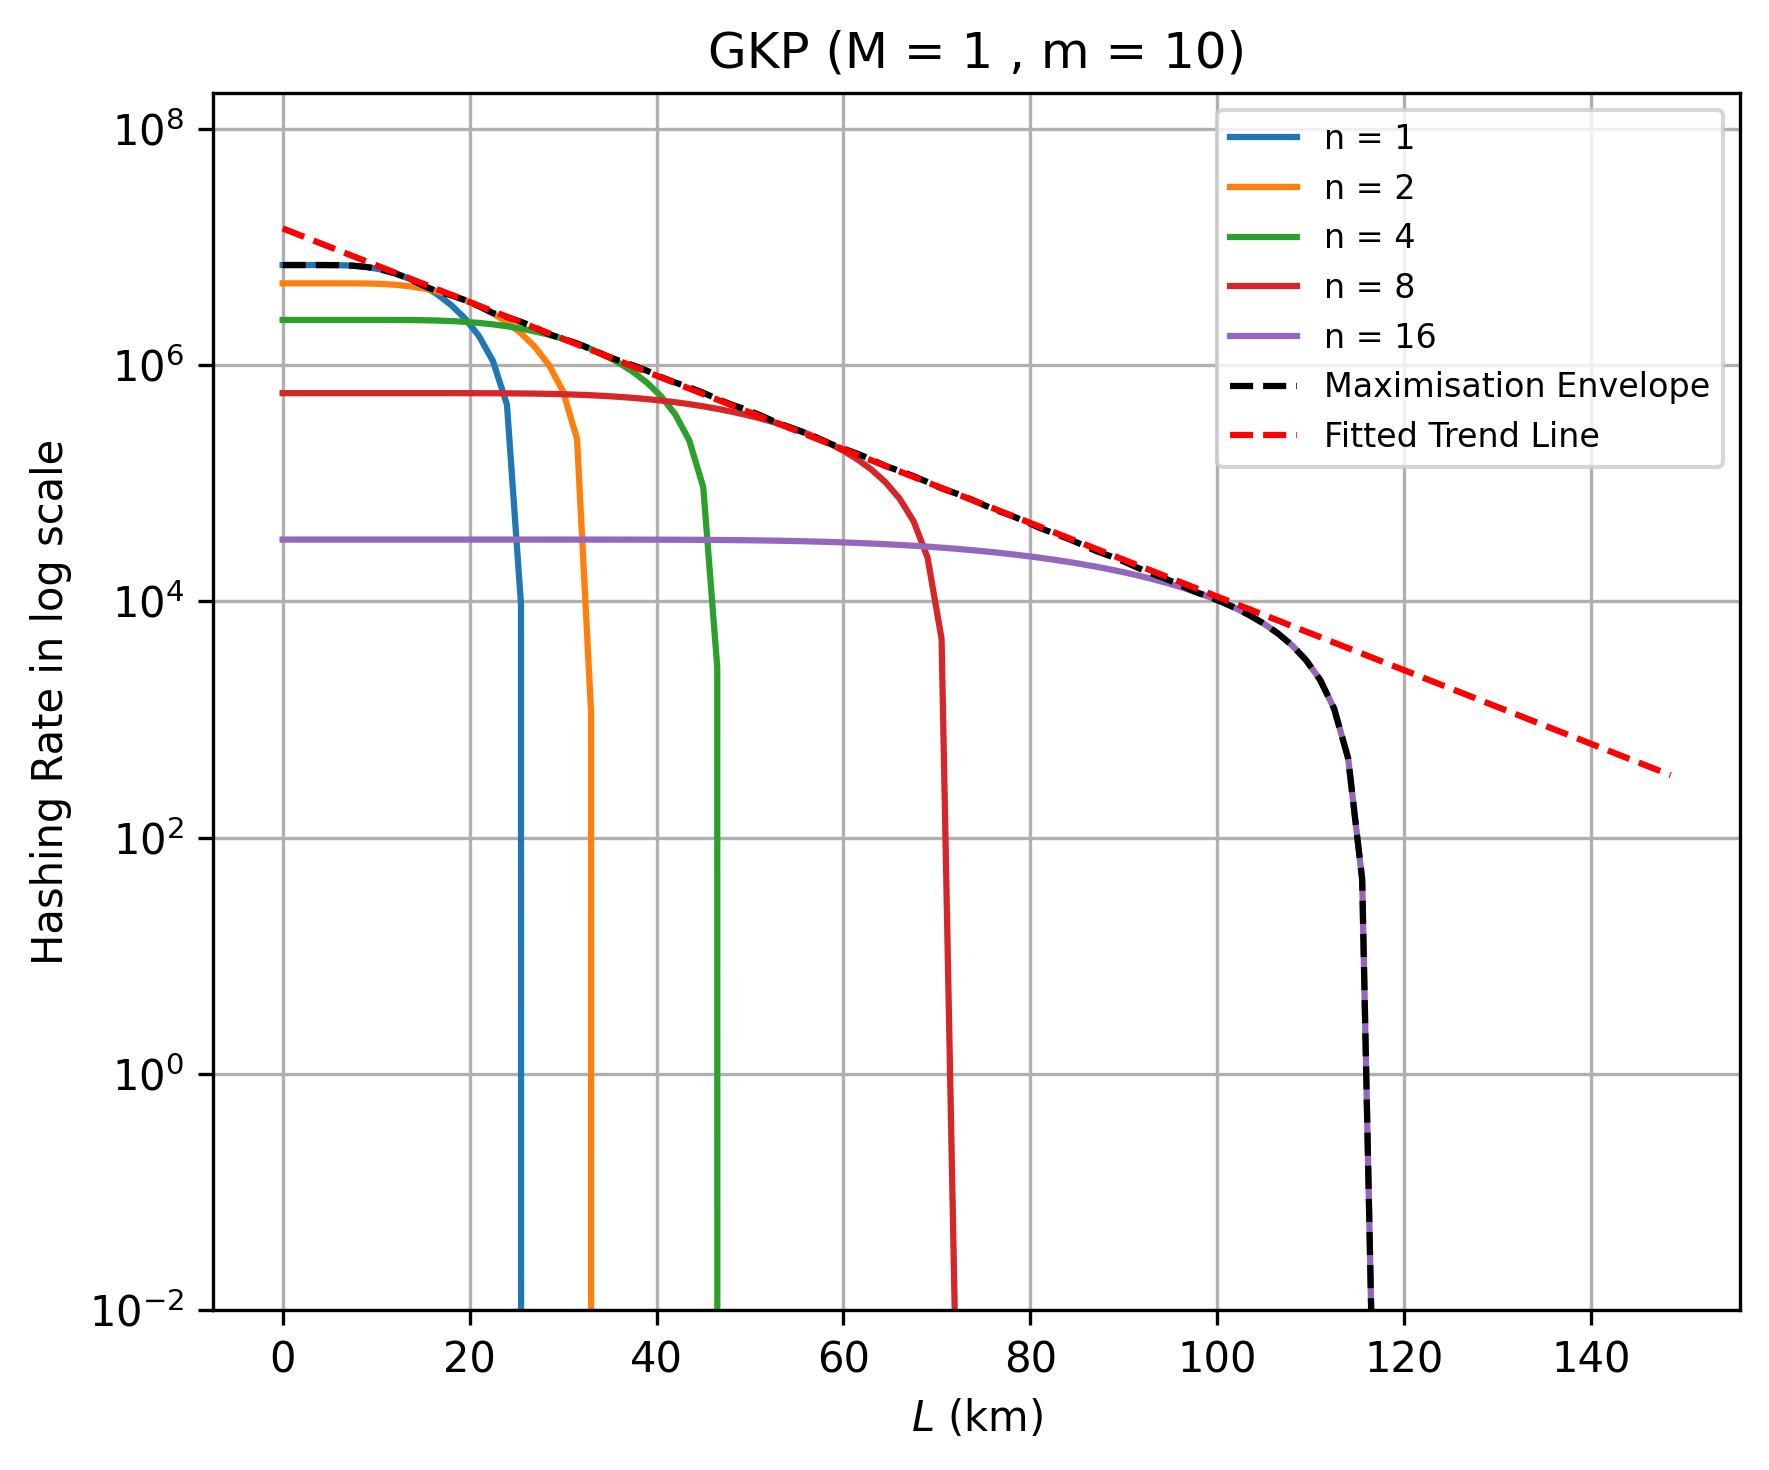

In [126]:
fig, ax = plt.subplots(figsize=(6, 5),dpi = 300)
ax.set_yscale("log")
ax.set_title("GKP (M = 1 , m = 10)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e-2, top=2e8)
ax.grid(True)

n_vals = [1 , 2 , 4 , 8 , 16]
Ls = np.array(Ls)  # ensure it's an array
gkp_list = [rates1q , rates2q , rates4q , rates8q , rates16q]

color_cycle = plt.get_cmap("tab10")

for i, rate_curve in enumerate(gkp_list):
    n = n_vals[i]
    color = color_cycle(i)
    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)

n_scan_vals = np.arange(1 , 17)
rate_envelope = []
for L in Ls:
    best_rate = 0.0
    for n in n_scan_vals:
        rate = optimal_qudit_hashing_rate(Nreg , squeezing_db , L , n , M , q , tau , m , loss_model = "preamplified")
        best_rate = max(best_rate , rate)
    rate_envelope.append(best_rate)
rate_envelope = np.array(rate_envelope)
ax.plot(Ls, rate_envelope, color="black", linestyle="--", linewidth=1.5, label="Maximisation Envelope")

log_env = np.log(rate_envelope)
fit_mask = (Ls > 10) & (Ls < 90)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env = np.exp(slope * Ls + intercept)

ax.plot(Ls, predicted_env, color="red", linestyle="--", label="Fitted Trend Line")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# GKP Qudit Envelope Analysis (Recreation of GKP qubit envelope plot)

In [137]:
def compute_qudit_envelope(Nreg, m, squeezing_db, Ls, M, q, tau, n_vals, n_scan_vals,
                           j_cutoff=30, loss_model="preamplified"):
    fixed_n_data = {n: {"rate": []} for n in n_vals}
    rate_envelope = []

    for L in Ls:
        best_rate = 0.0

        for n in n_scan_vals:
            rate, nu_opt = optimal_qudit_hashing_rate(
                Nreg, squeezing_db, L, n, M, q, tau, m,
                j_cutoff=j_cutoff,
                loss_model=loss_model,
                return_nu=True
            )

            true_hashing_rate = max(rate, 0.0)
            best_rate = max(best_rate, true_hashing_rate)

            if n in fixed_n_data:
                fixed_n_data[n]["rate"].append(true_hashing_rate)

        rate_envelope.append(best_rate)

    rate_envelope = np.array(rate_envelope)

    for n in n_vals:
        fixed_n_data[n]["rate"] = np.array(fixed_n_data[n]["rate"])

    fit_mask = (Ls > 10) & (Ls < 40) & np.isfinite(rate_envelope) & (rate_envelope > 0)
    slope, intercept, *_ = linregress(Ls[fit_mask], np.log(rate_envelope[fit_mask]))

    return {
        "m": m,
        "Linear Regression slope": slope,
        "Linear Regression intercept": intercept,
        "Hashing Rate curves": rate_envelope,
        "fixed_n_data": fixed_n_data,
    }

In [138]:
Ls = np.arange(0, 50, 0.1)

Nreg = 2          # d = 2 check
squeezing_db = 20  # matches sigma^2 = 0.01
M = 1
q = 0.7
tau = 1e-8

m_values = np.arange(1, 30)
n_vals = [1, 2, 4, 8, 16]
n_scan_vals = np.arange(1, 17)

results_by_m = {}
envs = {}

for m in m_values:
    print("Computing envelope for m =", m)

    out = compute_qudit_envelope(
        Nreg, m, squeezing_db, Ls, M, q, tau, n_vals, n_scan_vals
    )

    predicted_env = np.exp(
        out["Linear Regression intercept"] + out["Linear Regression slope"] * Ls
    )

    results_by_m[m] = out
    envs[m] = predicted_env

Computing envelope for m = 1
Computing envelope for m = 2
Computing envelope for m = 3
Computing envelope for m = 4
Computing envelope for m = 5


KeyboardInterrupt: 

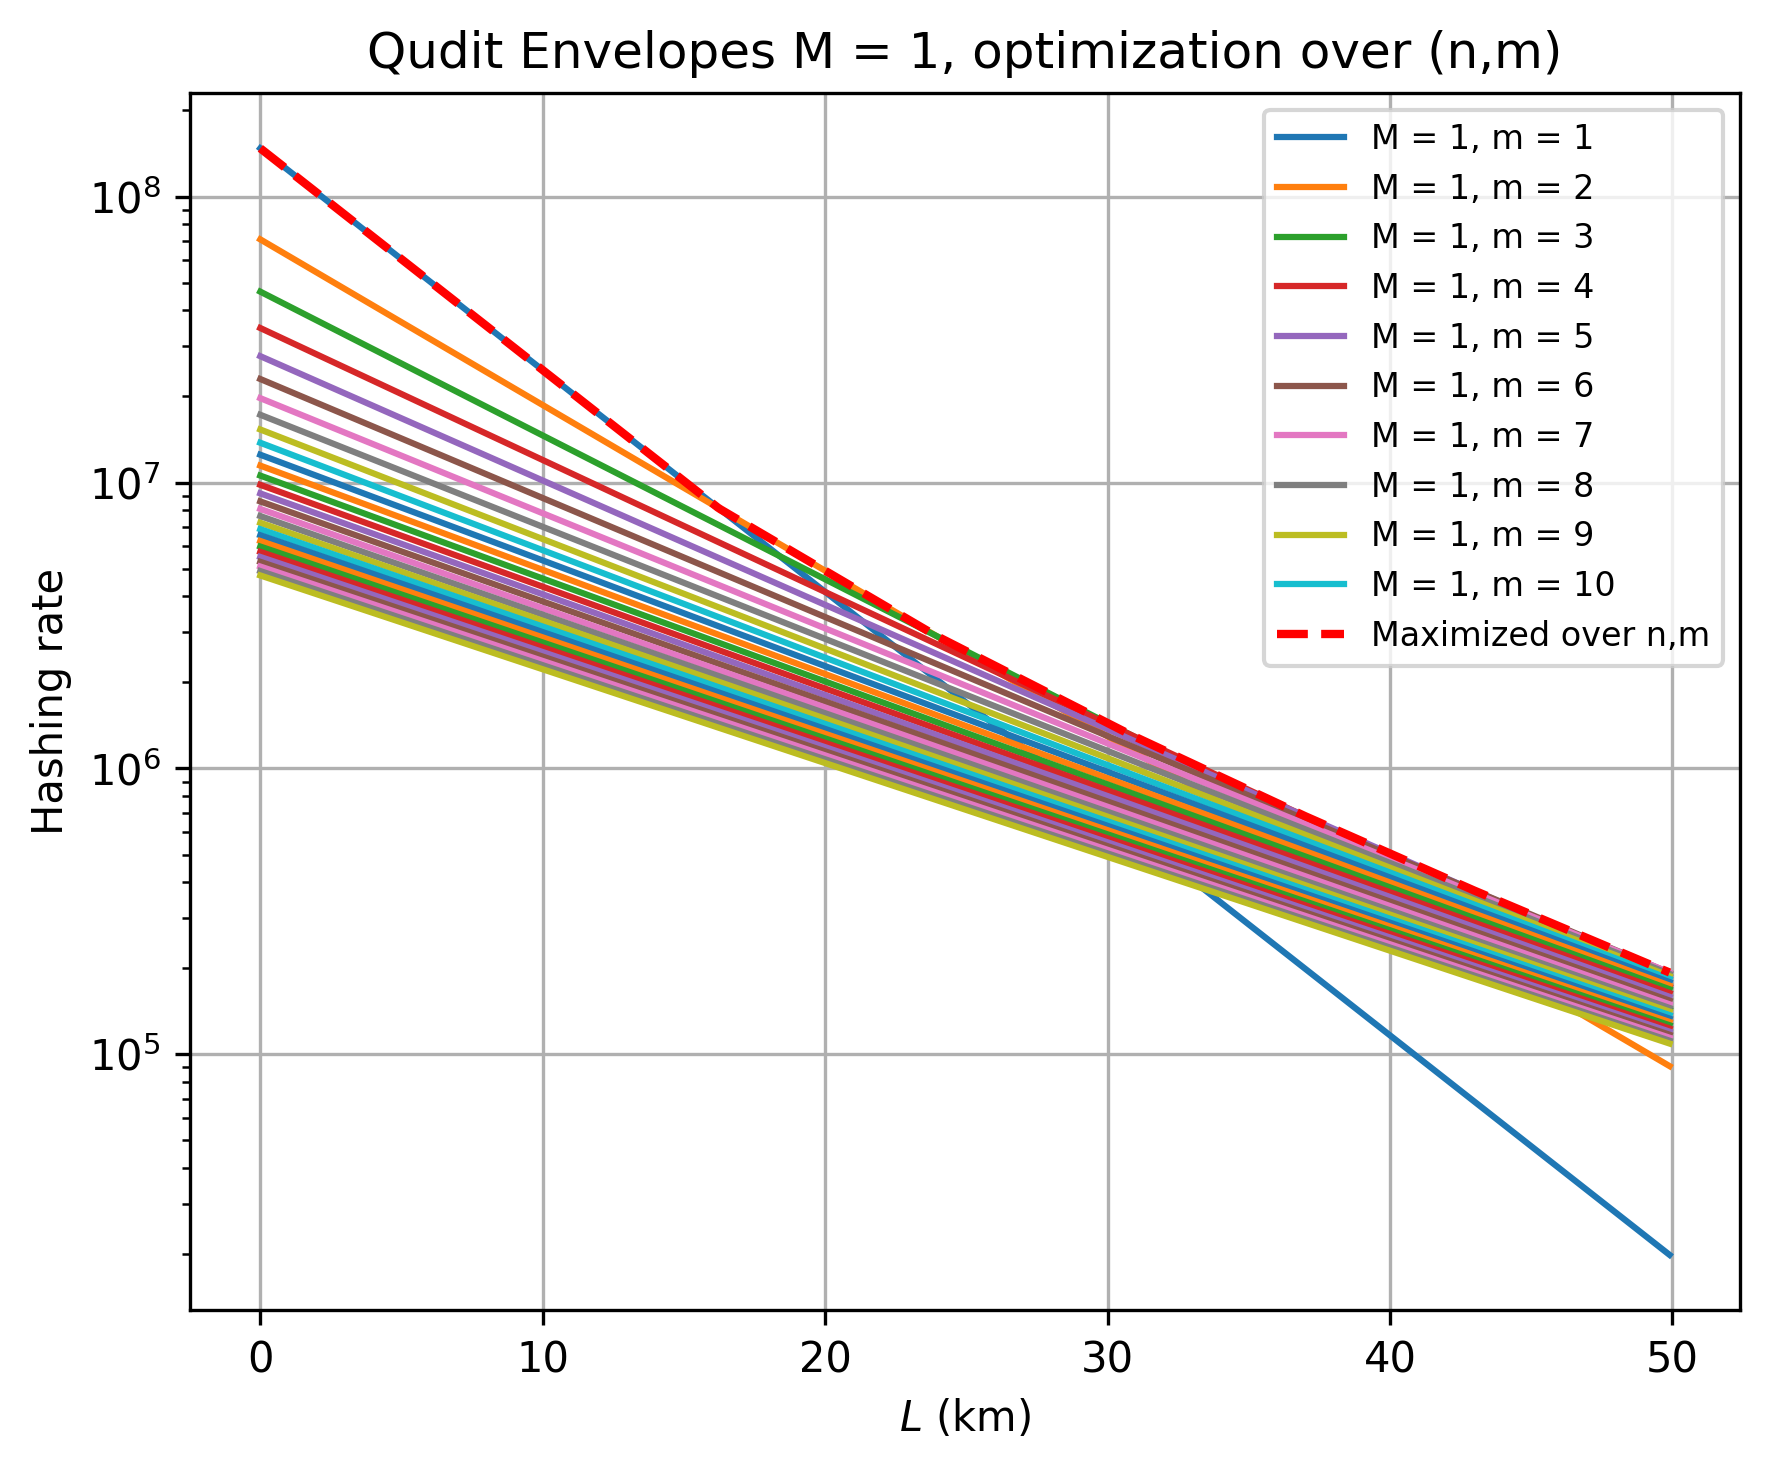

In [ ]:
gkp_env_matrix = np.array([envs[m] for m in m_values])
fully_maximized_gkp_env = np.max(gkp_env_matrix, axis=0)

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

ax.set_yscale("log")
ax.set_title("Qudit Envelopes M = 1, optimization over (n,m)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

for i, m in enumerate(m_values):
    label = f"M = 1, m = {m}" if i < 10 else None
    ax.plot(Ls, envs[m], color=color_cycle(i % 10), linestyle="-", label=label)

ax.plot(
    Ls,
    fully_maximized_gkp_env,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Maximized over n,m"
)

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

This plot exactly matches the results from the qubit simulations from above

# Multi-value Nreg analysis

In [136]:
import numpy as np
import matplotlib.pyplot as plt

Nreg_values = [1, 2, 3, 4, 5, 6]

Ls_cmp = np.arange(0, 50, 0.1)
M = 1
q = 0.7
tau = 1e-8
squeezing_db = 20
m_values = np.arange(1, 30)
n_vals = [1, 2, 4, 8, 16]
n_scan_vals = np.arange(1, 17)

gkp_max_envelopes = {}
gkp_details = {}   # stores both envs and results_by_m

for Nreg in Nreg_values:
    print(f"Computing GKP envelopes for Nreg = {Nreg}")

    results_by_m = {}
    envs = {}

    for m in m_values:
        out = compute_qudit_envelope(
            Nreg, m, squeezing_db, Ls_cmp, M, q, tau, n_vals, n_scan_vals
        )

        predicted_env = np.exp(
            out["Linear Regression intercept"] + out["Linear Regression slope"] * Ls_cmp
        )

        results_by_m[m] = out
        envs[m] = predicted_env

    gkp_env_matrix = np.array([envs[m] for m in m_values])
    gkp_max_envelopes[Nreg] = np.max(gkp_env_matrix, axis=0)

    gkp_details[Nreg] = {
        "results_by_m": results_by_m,
        "envs": envs,
    }

Computing GKP envelopes for Nreg = 1


/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(6,5), dpi=1000)

ax.set_yscale("log")
ax.set_title("GKP vs DR Envelopes")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

# Plot one GKP curve for each register size
for i, Nreg in enumerate(Nreg_values):
    ax.plot(
        Ls_cmp,
        gkp_max_envelopes[Nreg],
        color=color_cycle(i),
        linewidth=2,
        label=fr"GKP $N_{{\rm reg}}={Nreg}$ ($d={2**Nreg}$)"
    )

# Dual-rail envelope
ax.plot(
    Ls_cmp,
    fully_maximized_env,
    color="black",
    linewidth=2,
    linestyle="--",
    label="Dual rail"
)

# PLOB bound
ax.plot(
    Ls_cmp,
    PLOB_bound_tab,
    color="red",
    linewidth=2,
    linestyle=":",
    label="PLOB bound"
)

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
def compute_qudit_envelope(Nreg, m, squeezing_db, Ls, M, q, tau, n_vals, n_scan_vals,
                           j_cutoff=30, loss_model="preamplified"):
    fixed_n_data = {n: {"rate": []} for n in n_vals}
    rate_envelope = []

    for L in Ls:
        best_rate = 0.0

        for n in n_scan_vals:
            rate, _ = optimal_qudit_hashing_rate(
                Nreg, squeezing_db, L, n, M, q, tau, m,
                j_cutoff=j_cutoff,
                loss_model=loss_model,
                return_nu=True
            )

            rate = max(rate, 0.0)
            best_rate = max(best_rate, rate)

            if n in fixed_n_data:
                fixed_n_data[n]["rate"].append(rate)

        rate_envelope.append(best_rate)

    rate_envelope = np.array(rate_envelope)

    for n in n_vals:
        fixed_n_data[n]["rate"] = np.array(fixed_n_data[n]["rate"])

    return {
        "m": m,
        "Hashing Rate curves": rate_envelope,   # black dashed envelope for this m
        "fixed_n_data": fixed_n_data,
    }

In [ ]:
Ls = np.arange(0, 50, 0.1)
Nreg = 2
squeezing_db = 20
M = 1
q = 0.7
tau = 1e-8

m_values = np.arange(1, 30)
n_vals = [1, 2, 4, 8, 16]
n_scan_vals = np.arange(1, 17)

results_by_m = {}
envelope_by_m = {}

for m in m_values:
    print(f"Computing envelope for m = {m}")

    out = compute_qudit_envelope(
        Nreg, m, squeezing_db, Ls, M, q, tau, n_vals, n_scan_vals
    )

    results_by_m[m] = out
    envelope_by_m[m] = out["Hashing Rate curves"]


black_env_matrix = np.array([envelope_by_m[m] for m in m_values])
blue_env = np.max(black_env_matrix, axis=0)


fit_mask = (Ls > 10) & (Ls < 40) & np.isfinite(blue_env) & (blue_env > 0)
slope, intercept, *_ = linregress(Ls[fit_mask], np.log(blue_env[fit_mask]))
predicted_blue_env = np.exp(slope * Ls + intercept)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
ax.set_yscale("log")
ax.set_title("Qudit envelopes, Nreg = 2")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

for i, m in enumerate(m_values):
    ax.plot(Ls, envelope_by_m[m], color=plt.get_cmap("tab10")(i % 10), alpha=0.6)

ax.plot(Ls, blue_env, color="blue", linestyle="--", linewidth=2, label="Max over m")
ax.plot(Ls, predicted_blue_env, color="red", linestyle="--", linewidth=2, label="Linear fit")

ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def compute_qudit_envelope(Nreg,m,squeezing_db,Ls,M,q,tau,n_vals,n_scan_vals,j_cutoff=30,loss_model="preamplified"):
    # Fixing m and varying n
    # Obtaining HR curves
    hashing_rate_curves_for_fixed_n = {n: {"rate": []} for n in n_vals}
 
    maximisation_over_fixed_n_for_fixed_m = []

    for L in Ls:

        best_rate = 0.0

        for n in n_scan_vals:

            rate, _ = optimal_qudit_hashing_rate(Nreg,squeezing_db,L,n,M,q,tau,m,j_cutoff=j_cutoff,loss_model=loss_model,return_nu=True)

            rate = max(rate, 0.0)
            best_rate = max(best_rate, rate)

            if n in hashing_rate_curves_for_fixed_n:
                hashing_rate_curves_for_fixed_n[n]["rate"].append(rate)

        maximisation_over_fixed_n_for_fixed_m.append(best_rate)

    maximisation_over_fixed_n_for_fixed_m = np.array(maximisation_over_fixed_n_for_fixed_m)

    for n in n_vals:
        hashing_rate_curves_for_fixed_n[n]["rate"] = np.array(hashing_rate_curves_for_fixed_n[n]["rate"])

    return {
        "m": m,
        "maximisation_over_fixed_n_for_fixed_m":
            maximisation_over_fixed_n_for_fixed_m,
        "hashing_rate_curves_for_fixed_n":
            hashing_rate_curves_for_fixed_n,
    }


Ls = np.arange(0, 50, 0.1)

Nreg = 2
squeezing_db = 20
M = 1
q = 0.7
tau = 1e-8

m_values = np.arange(1, 30)
n_vals = [1, 2, 4, 8, 16]
n_scan_vals = np.arange(1, 17)

results_by_m = {}

maximisation_over_fixed_n_for_fixed_m = {}

for m in m_values:

    print(f"Computing envelope for m = {m}")

    out = compute_qudit_envelope(Nreg,m,squeezing_db,Ls,M,q,tau,n_vals,n_scan_vals)

    results_by_m[m] = out

    maximisation_over_fixed_n_for_fixed_m[m] = (
        out["maximisation_over_fixed_n_for_fixed_m"]
    )


maximisation_over_fixed_n_for_all_m = np.array(
    [
        maximisation_over_fixed_n_for_fixed_m[m]
        for m in m_values
    ]
)

maximisation_over_all_m_for_fixed_Nreg = np.max(
    maximisation_over_fixed_n_for_all_m,
    axis=0,
)


fit_mask = (
    (Ls > 10)
    & (Ls < 40)
    & np.isfinite(maximisation_over_all_m_for_fixed_Nreg)
    & (maximisation_over_all_m_for_fixed_Nreg > 0)
)

slope, intercept, *_ = linregress(
    Ls[fit_mask],
    np.log(maximisation_over_all_m_for_fixed_Nreg[fit_mask]),
)

linear_regression_fit_to_maximisation_over_all_m_for_fixed_Nreg = np.exp(
    slope * Ls + intercept
)